# 05 — Damage Modelling

## Main question

**How accurately can the project estimate reported aircraft-damage probability for a defined wildlife-strike scenario?**

This notebook models `INDICATED_DAMAGE` as the primary binary target. Every probability is conditional on a wildlife strike having already been reported. The model does **not** estimate the probability that a strike will occur.

### Modelling decisions carried forward from Notebook 02

- Use the locked chronological periods:
  - training: 1990–2018,
  - validation: 2019–2021,
  - final test: 2022–2024.
- Protect the final test period from fitting, tuning, threshold selection, and model selection.
- Use only the canonical feature lists approved in Notebook 02.
- Compare a geographic model using `STATE` and `FAAREGION` with an airport-aware model that additionally uses `AIRPORT_ID`.
- Treat `NUM_STRUCK` as an ordered category rather than an exact count.
- Compare a majority baseline, logistic regression, Random Forest, and XGBoost.
- Use PR-AUC as the main discrimination metric because reported damage is uncommon, while also reporting ROC-AUC, precision, recall, F1, F2, Brier score, log loss, and confusion matrices.
- Select the main operating threshold by validation F1. Also report F2 and 70%/80% recall operating points as sensitivity analyses.
- Preserve model probabilities for calibration in Notebook 06.

The notebook exports a readable pre-model dataset and a transformed model-input sample with no missing values. The transformed sample is for demonstration; learned preprocessing remains inside each fitted pipeline.


## 1. Environment and reproducibility

`xgboost` is installed explicitly because it is not part of the Python standard library or scikit-learn. The command is safe to rerun in Jupyter environments.


In [1]:
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score, accuracy_score,
    f1_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve, brier_score_loss, log_loss
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)


Python: 3.12.9
pandas: 2.2.3


## 2. Portable paths

The notebook searches upward from the current working directory. It also accepts the uploaded filenames used during review, which makes the notebook easier to test outside the final repository structure.


In [3]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "faa_strikes_binary_model.csv").exists():
        ROOT = candidate
        break

PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "05_damage_modelling"
MODEL_DIR = ROOT / "models" / "candidates"
DOCS_DIR = ROOT / "docs"

for directory in [PROCESSED_DIR, OUTPUT_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

binary_candidates = [
    PROCESSED_DIR / "faa_strikes_binary_model.csv",
    ROOT / "faa_strikes_binary_model.csv",
    Path("/mnt/data/faa_strikes_binary_model(1).csv"),
]

feature_candidates = [
    DOCS_DIR / "feature_lists.json",
    ROOT / "feature_lists.json",
]

BINARY_PATH = next((p for p in binary_candidates if p.exists()), None)
FEATURE_LIST_PATH = next((p for p in feature_candidates if p.exists()), None)

if BINARY_PATH is None:
    raise FileNotFoundError(
        "faa_strikes_binary_model.csv was not found. Run Notebook 02 first "
        "or place its export in data/processed/."
    )

print("Repository root:", ROOT)
print("Binary dataset:", BINARY_PATH)
print("Feature-list artifact:", FEATURE_LIST_PATH or "not found; verified fallback will be used")

Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Binary dataset: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_binary_model.csv
Feature-list artifact: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\docs\feature_lists.json


## 3. Load and verify the restricted modelling dataset

The binary file is a **pre-model dataset**, not the final numerical matrix. It may retain missing numerical values because imputation must be learned from the training period inside each pipeline.

The checks below demonstrate its dimensions, memory use, temporal coverage, target prevalence, and missingness.


In [4]:
df = pd.read_csv(BINARY_PATH, low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Approximate memory: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
display(df.head())
display(df.info())

Rows: 319,107
Columns: 25
Approximate memory: 292.8 MB


,INDICATED_DAMAGE,SEASON,MONTH_SIN,MONTH_COS,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_CLASS,AC_MASS_GROUP,TYPE_ENG,NUM_ENGS,WARNED,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME_OF_DAY,SKY,PRECIPITATION,STATE,FAAREGION,AIRPORT_ID,TEMPORAL_SPLIT,TARGET_CONFLICT_FLAG,INCIDENT_YEAR,INDEX_NR
0,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CA,AWP,KSMF,train_1990_2018,0,1996,608242
1,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CO,ANM,KDEN,train_1990_2018,0,1996,608243
2,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,NE,ACE,KOMA,train_1990_2018,0,1996,608244
3,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Approach,1000.0,NaN,Not reported,Not reported,Not reported,DC,AEA,KIAD,train_1990_2018,0,1996,608245
4,1,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Climb,5000.0,NaN,Not reported,Not reported,Not reported,NY,AEA,KLGA,train_1990_2018,0,1996,608246


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319107 entries, 0 to 319106
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDICATED_DAMAGE      319107 non-null  int64  
 1   SEASON                319107 non-null  object 
 2   MONTH_SIN             319107 non-null  float64
 3   MONTH_COS             319107 non-null  float64
 4   WILDLIFE_TYPE         319107 non-null  object 
 5   SIZE                  319107 non-null  object 
 6   NUM_STRUCK            319107 non-null  object 
 7   AC_CLASS              319107 non-null  object 
 8   AC_MASS_GROUP         319107 non-null  object 
 9   TYPE_ENG              319107 non-null  object 
 10  NUM_ENGS              227893 non-null  float64
 11  WARNED                319107 non-null  object 
 12  PHASE_OF_FLIGHT       319107 non-null  object 
 13  HEIGHT                160917 non-null  float64
 14  SPEED                 100786 non-null  float64
 15  

None

In [5]:
required_columns = {
    "INDICATED_DAMAGE", "TEMPORAL_SPLIT", "INCIDENT_YEAR",
    "INDEX_NR", "TARGET_CONFLICT_FLAG"
}
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"

assert set(df["INDICATED_DAMAGE"].dropna().unique()).issubset({0, 1})
assert df["INDICATED_DAMAGE"].notna().all()
assert df["INDEX_NR"].is_unique, "INDEX_NR should identify one retained incident."

split_summary = (
    df.groupby("TEMPORAL_SPLIT")
      .agg(
          rows=("INDEX_NR", "size"),
          first_year=("INCIDENT_YEAR", "min"),
          last_year=("INCIDENT_YEAR", "max"),
          damaged=("INDICATED_DAMAGE", "sum"),
          damage_rate=("INDICATED_DAMAGE", "mean"),
      )
      .reset_index()
)
split_summary["damage_rate_pct"] = 100 * split_summary["damage_rate"]
display(split_summary.round(3))

missing_summary = (
    df.isna().mean().mul(100)
      .rename("missing_pct")
      .to_frame()
      .query("missing_pct > 0")
      .sort_values("missing_pct", ascending=False)
)
display(missing_summary.round(2))

,TEMPORAL_SPLIT,rows,first_year,last_year,damaged,damage_rate,damage_rate_pct
0,test_2022_2024,59219,2022,2024,2246,0.038,3.793
1,train_1990_2018,215274,1990,2018,16737,0.078,7.775
2,validation_2019_2021,44614,2019,2021,1925,0.043,4.315


,missing_pct
SPEED,68.42
HEIGHT,49.57
NUM_ENGS,28.58


### Interpretation

A lower damage rate in later periods is evidence of temporal distribution shift. It may reflect changes in strike circumstances, aircraft fleets, reporting practice, or data completeness. The chronological design therefore provides a more demanding and relevant assessment than a random split.

Missing values in `HEIGHT`, `SPEED`, or `NUM_ENGS` do not mean that Notebook 02 failed. They remain visible so that their imputation statistics are estimated only from training records.


## 4. Canonical feature lists and leakage assertion

Notebook 02 remains the source of truth. When its JSON artifact is available, this notebook loads it directly. The fallback lists reproduce the approved definitions and are checked against the dataset.

`INCIDENT_YEAR`, `TEMPORAL_SPLIT`, `INDEX_NR`, and `TARGET_CONFLICT_FLAG` are retained for validation or audit purposes but are not predictors.


In [6]:
fallback_feature_lists = {
    "core_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED"
    ],
    "extended_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION"
    ],
    "airport_aware_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
        "AIRPORT_ID"
    ],
    "primary_target": "INDICATED_DAMAGE",
    "seed": SEED,
}

if FEATURE_LIST_PATH is not None:
    with open(FEATURE_LIST_PATH, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)
else:
    feature_lists = fallback_feature_lists.copy()
    warnings.warn(
        "feature_lists.json was not found. The approved Notebook 02 fallback "
        "is being used. Regenerate the JSON artifact before final submission."
    )

TARGET = feature_lists.get("primary_target", "INDICATED_DAMAGE")
CORE_FEATURES = [c for c in feature_lists["core_features"] if c in df.columns]
EXTENDED_FEATURES = [c for c in feature_lists["extended_features"] if c in df.columns]
AIRPORT_AWARE_FEATURES = [
    c for c in feature_lists["airport_aware_features"] if c in df.columns
]

feature_set_table = pd.DataFrame({
    "feature_set": ["core", "extended_geographic", "airport_aware"],
    "feature_count": [
        len(CORE_FEATURES), len(EXTENDED_FEATURES), len(AIRPORT_AWARE_FEATURES)
    ],
    "includes_state": [
        "STATE" in CORE_FEATURES, "STATE" in EXTENDED_FEATURES,
        "STATE" in AIRPORT_AWARE_FEATURES
    ],
    "includes_region": [
        "FAAREGION" in CORE_FEATURES, "FAAREGION" in EXTENDED_FEATURES,
        "FAAREGION" in AIRPORT_AWARE_FEATURES
    ],
    "includes_airport_id": [
        "AIRPORT_ID" in CORE_FEATURES, "AIRPORT_ID" in EXTENDED_FEATURES,
        "AIRPORT_ID" in AIRPORT_AWARE_FEATURES
    ],
})
display(feature_set_table)

assert set(EXTENDED_FEATURES).issubset(AIRPORT_AWARE_FEATURES)
assert "AIRPORT_ID" not in EXTENDED_FEATURES
assert "AIRPORT_ID" in AIRPORT_AWARE_FEATURES

,feature_set,feature_count,includes_state,includes_region,includes_airport_id
0,core,11,False,False,False
1,extended_geographic,19,True,True,False
2,airport_aware,20,True,True,True


In [7]:
forbidden_predictors = {
    "DAMAGE_LEVEL", "EFFECT", "EFFECT_OTHER", "AOS",
    "COST_REPAIRS", "COST_OTHER", "COST_REPAIRS_INFL_ADJ",
    "COST_OTHER_INFL_ADJ", "NR_INJURIES", "NR_FATALITIES",
    "INCIDENT_YEAR", "TEMPORAL_SPLIT", "INDEX_NR", "TARGET_CONFLICT_FLAG"
}
forbidden_predictors |= {
    c for c in df.columns if c.startswith(("DAM_", "STR_", "ING_"))
}

for set_name, features in {
    "core": CORE_FEATURES,
    "extended": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}.items():
    leaked = sorted(set(features) & forbidden_predictors)
    assert not leaked, f"{set_name} contains forbidden predictors: {leaked}"

print("Leakage assertions passed.")

Leakage assertions passed.


## 5. Demonstration export: readable pre-model dataset

This output is the cleaned, human-readable table that individuals can inspect. It includes the target, all approved airport-aware predictors, split metadata, and identifiers. It is not falsely presented as an already imputed matrix.


In [8]:
PREMODEL_COLUMNS = list(dict.fromkeys(
    [TARGET] + AIRPORT_AWARE_FEATURES +
    ["TEMPORAL_SPLIT", "INCIDENT_YEAR", "INDEX_NR", "TARGET_CONFLICT_FLAG"]
))

premodel_df = df[PREMODEL_COLUMNS].copy()
premodel_path = PROCESSED_DIR / "faa_strikes_binary_model_ready.csv"
premodel_df.to_csv(premodel_path, index=False)

premodel_info = pd.DataFrame([{
    "file": premodel_path.name,
    "rows": premodel_df.shape[0],
    "columns": premodel_df.shape[1],
    "file_size_mb": premodel_path.stat().st_size / 1024**2,
    "cells_missing": int(premodel_df.isna().sum().sum()),
    "purpose": "Readable cleaned dataset before learned preprocessing"
}])
display(premodel_info.round(2))
display(premodel_df.head())

,file,rows,columns,file_size_mb,cells_missing,purpose
0,faa_strikes_binary_model_ready.csv,319107,25,55.39,467725,Readable cleaned dataset before learned prepro...


,INDICATED_DAMAGE,SEASON,MONTH_SIN,MONTH_COS,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_CLASS,AC_MASS_GROUP,TYPE_ENG,NUM_ENGS,WARNED,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME_OF_DAY,SKY,PRECIPITATION,STATE,FAAREGION,AIRPORT_ID,TEMPORAL_SPLIT,INCIDENT_YEAR,INDEX_NR,TARGET_CONFLICT_FLAG
0,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CA,AWP,KSMF,train_1990_2018,1996,608242,0
1,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CO,ANM,KDEN,train_1990_2018,1996,608243,0
2,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,NE,ACE,KOMA,train_1990_2018,1996,608244,0
3,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Approach,1000.0,NaN,Not reported,Not reported,Not reported,DC,AEA,KIAD,train_1990_2018,1996,608245,0
4,1,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Climb,5000.0,NaN,Not reported,Not reported,Not reported,NY,AEA,KLGA,train_1990_2018,1996,608246,0


## 6. Locked chronological partitions

The project retains the chronological periods established in Notebook 02:

- training: 1990–2018,
- validation: 2019–2021,
- locked final test: 2022–2024.

Hyperparameter selection is performed only within the 1990–2018 training
period. Rather than using a single development/tuning split, chronological
cross-validation is used so that each fold trains on earlier observations and
evaluates on later observations.

The 2019–2021 validation period is not used for hyperparameter selection.
The 2022–2024 final test period remains completely untouched in this notebook.


In [9]:
train_mask = df["TEMPORAL_SPLIT"].eq("train_1990_2018")
validation_mask = df["TEMPORAL_SPLIT"].eq("validation_2019_2021")
test_mask = df["TEMPORAL_SPLIT"].eq("test_2022_2024")


y_train = df.loc[train_mask, TARGET].astype(int)
y_validation = df.loc[validation_mask, TARGET].astype(int)
y_test_locked = df.loc[test_mask, TARGET].astype(int)

partition_table = pd.DataFrame([
    [
        "training_for_chronological_cv",
        int(train_mask.sum()),
        1990,
        2018,
        df.loc[train_mask, TARGET].mean()
    ],
    [
        "official_validation",
        int(validation_mask.sum()),
        2019,
        2021,
        df.loc[validation_mask, TARGET].mean()
    ],
    [
        "locked_final_test",
        int(test_mask.sum()),
        2022,
        2024,
        df.loc[test_mask, TARGET].mean()
    ],
], columns=[
    "partition",
    "rows",
    "first_year",
    "last_year",
    "damage_rate"
])

partition_table["damage_rate_pct"] = (
    100 * partition_table["damage_rate"]
)

display(partition_table.round(3))

assert not (train_mask & validation_mask).any()
assert not (train_mask & test_mask).any()
assert not (validation_mask & test_mask).any()

,partition,rows,first_year,last_year,damage_rate,damage_rate_pct
0,training_for_chronological_cv,215274,1990,2018,0.078,7.775
1,official_validation,44614,2019,2021,0.043,4.315
2,locked_final_test,59219,2022,2024,0.038,3.793


### Chronological cross-validation design


In [10]:
train_cv_df = (
    df.loc[train_mask]
      .sort_values(["INCIDENT_YEAR", "INDEX_NR"])
      .copy()
)

TRAIN_YEARS = sorted(train_cv_df["INCIDENT_YEAR"].unique())

print(
    f"Training period available for CV: "
    f"{min(TRAIN_YEARS)}–{max(TRAIN_YEARS)}"
)
print(f"Training observations: {len(train_cv_df):,}")

Training period available for CV: 1990–2018
Training observations: 215,274


In [11]:
CV_FOLDS = [
    {
        "fold": 1,
        "train_years": range(1990, 2004),
        "validation_years": range(2004, 2007),
    },
    {
        "fold": 2,
        "train_years": range(1990, 2007),
        "validation_years": range(2007, 2010),
    },
    {
        "fold": 3,
        "train_years": range(1990, 2010),
        "validation_years": range(2010, 2013),
    },
    {
        "fold": 4,
        "train_years": range(1990, 2013),
        "validation_years": range(2013, 2016),
    },
    {
        "fold": 5,
        "train_years": range(1990, 2016),
        "validation_years": range(2016, 2019),
    },
]

cv_summary = []

for spec in CV_FOLDS:
    fold_train_mask = (
        train_mask
        & df["INCIDENT_YEAR"].isin(spec["train_years"])
    )
    fold_val_mask = (
        train_mask
        & df["INCIDENT_YEAR"].isin(spec["validation_years"])
    )

    cv_summary.append({
        "fold": spec["fold"],
        "train_start": min(spec["train_years"]),
        "train_end": max(spec["train_years"]),
        "validation_start": min(spec["validation_years"]),
        "validation_end": max(spec["validation_years"]),
        "train_rows": int(fold_train_mask.sum()),
        "validation_rows": int(fold_val_mask.sum()),
        "train_damage_rate": df.loc[
            fold_train_mask, TARGET
        ].mean(),
        "validation_damage_rate": df.loc[
            fold_val_mask, TARGET
        ].mean(),
    })

cv_summary = pd.DataFrame(cv_summary)
display(cv_summary.round(4))

,fold,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_damage_rate,validation_damage_rate
0,1,1990,2003,2004,2006,55034,21179,0.1377,0.0870
1,2,1990,2006,2007,2009,76213,24898,0.1236,0.0684
2,3,1990,2009,2010,2012,101111,30950,0.1100,0.0574
3,4,1990,2012,2013,2015,132061,38873,0.0977,0.0471
4,5,1990,2015,2016,2018,170934,44340,0.0862,0.0452


Chronological cross-validation differs from ordinary random cross-validation.
Rows are ordered by time, and each validation fold occurs after the records
used to fit that fold.

This prevents future training-period observations from being used to predict
earlier observations. Preprocessing remains inside the pipeline, so
imputation, scaling, and category encoding are also fitted separately within
each training fold.


## 7. Preprocessing design

`NUM_STRUCK` is represented by its documented order:

1. `1`
2. `2–10`
3. `11–100`
4. `More than 100`

`Unknown` and `Not reported` are not assigned artificial counts. After most-frequent imputation, the ordinal encoder maps the observed ranges to `0`–`3`, preserving their order from one reported strike through more than 100. The value `-1` is reserved for an unexpected category not observed during fitting. The encoded values represent ordered groups, not exact wildlife counts.

Other categorical variables are one-hot encoded. Rare categories are grouped using a threshold learned from training data only. Numerical variables are median-imputed. Logistic regression also standardizes numerical inputs.

The one-hot output remains sparse, which is important for `AIRPORT_ID`.


In [12]:
NUM_STRUCK_ORDER = [["1", "2–10", "11–100", "More than 100"]]

def make_preprocessor(features, scale_numeric=False, min_category_frequency=50):
    ordinal_features = [c for c in ["NUM_STRUCK"] if c in features]
    numeric_features = [
        c for c in features
        if c != "NUM_STRUCK" and pd.api.types.is_numeric_dtype(df[c])
    ]
    categorical_features = [
        c for c in features
        if c not in ordinal_features + numeric_features
    ]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler(with_mean=False)))

    transformers = []
    if numeric_features:
        transformers.append((
            "numeric",
            Pipeline(numeric_steps),
            numeric_features
        ))
    if ordinal_features:
        transformers.append((
            "num_struck_ordinal",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    categories=NUM_STRUCK_ORDER,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1
                ))
            ]),
            ordinal_features
        ))
    if categorical_features:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(
                    strategy="constant", fill_value="Not reported"
                )),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=min_category_frequency,
                    sparse_output=True
                ))
            ]),
            categorical_features
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
        verbose_feature_names_out=True
    )

preprocessing_design = pd.DataFrame([
    ["NUM_STRUCK", "Ordinal encoding", "Ordered ranges; unknown/unreported remain separate"],
    ["Other categorical fields", "Impute explicit label + sparse one-hot", "Nominal categories"],
    ["Numerical fields", "Training median", "No global imputation"],
    ["Rare categories", "Training-fitted grouping", "Reduces sparse unstable columns"],
], columns=["field_type", "treatment", "reason"])
display(preprocessing_design)

,field_type,treatment,reason
0,NUM_STRUCK,Ordinal encoding,Ordered ranges; unknown/unreported remain sepa...
1,Other categorical fields,Impute explicit label + sparse one-hot,Nominal categories
2,Numerical fields,Training median,No global imputation
3,Rare categories,Training-fitted grouping,Reduces sparse unstable columns


## 8. Candidate model construction

Four modelling references are retained:

- **Majority-prior baseline** establishes no-skill probability performance.
- **Logistic regression** provides an interpretable linear baseline.
- **Random Forest** captures non-linearities and interactions without requiring them to be specified manually.
- **XGBoost** provides a regularized gradient-boosting comparison and can consume the sparse encoded design matrix efficiently.

Hyperparameters are no longer defined in this section. They are specified in Section 10 and tuned separately by model family so that runtime, parameter compatibility, and model-specific decisions remain transparent.

The updated mappings and feature lists created upstream remain the source of truth. This notebook does not redefine wildlife, aircraft, geographic, or leakage mappings during model fitting.


In [13]:
def class_ratio(y):
    """Return the negative-to-positive class ratio from training observations only."""
    negatives = int((y == 0).sum())
    positives = int((y == 1).sum())
    if positives == 0:
        raise ValueError("The training fold contains no positive damage observations.")
    return negatives / positives


def make_pipeline(model_name, features, y_for_weight):
    """
    Construct a fresh preprocessing + estimator pipeline.

    Model-specific hyperparameters are deliberately left at stable defaults here
    because Section 10 supplies the values tested during chronological CV.
    """
    if model_name == "logistic":
        model = LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            penalty="l2",
            class_weight=None,
            random_state=SEED
        )
        prep = make_preprocessor(features, scale_numeric=True)

    elif model_name == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            class_weight=None,
            n_jobs=-1,
            random_state=SEED
        )
        prep = make_preprocessor(features, scale_numeric=False)

    elif model_name == "xgboost":
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
            scale_pos_weight=1.0
        )
        prep = make_preprocessor(features, scale_numeric=False)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline([
        ("preprocess", prep),
        ("model", model)
    ])


## 9. Evaluation helpers

### 9.1 Probability metrics

The target is strongly imbalanced because reported aircraft damage is uncommon
relative to non-damage. For this reason, overall accuracy is reported only as
a supporting diagnostic and is not used as the main model-selection criterion.
A model could achieve high accuracy by predicting the majority no-damage class
too often while failing to identify damaging strikes.

**PR-AUC is the primary discrimination metric.** It summarizes the trade-off
between precision and recall across many possible classification thresholds.
This makes it appropriate for evaluating how well a model prioritizes the rare
damage class without allowing the large number of true negatives to dominate
the score. Higher PR-AUC indicates better discrimination of damaging strikes.

**Brier score is used as the secondary probability-quality metric.** It measures
the average squared error between the predicted probability and the observed
binary outcome, so lower values indicate smaller probability error. Brier score
is particularly relevant because the final project requires probabilities for
calibration and Monte Carlo simulation rather than only hard damage/no-damage
classifications.


### 9.2 Classification metrics

ROC-AUC and log loss are retained as supporting probability and ranking metrics.
Precision, recall, F1, accuracy, and confusion-matrix counts are also reported
so that conventional classification behaviour remains visible.

During chronological cross-validation, threshold-dependent metrics are
calculated at a common threshold of **0.50 only for diagnostic comparison**.
Hyperparameters are selected primarily by mean PR-AUC and secondarily by mean
Brier score; they are not selected from 0.50-threshold accuracy or F1.


In [14]:
def probability_metrics(y_true, probabilities):
    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
    }


def classification_metrics_at_threshold(y_true, probabilities, threshold=0.5):
    """
    Return threshold-dependent classification metrics.

    During tuning, threshold=0.50 is used only as a common diagnostic
    comparison across candidate models. The final operating threshold is
    selected later from the official validation period.
    """
    predictions = (np.asarray(probabilities) >= threshold).astype(int)

    report = classification_report(
        y_true,
        predictions,
        output_dict=True,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    return {
        "threshold": threshold,
        # Positive class metrics
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"],
        "support_damage": int(report["1"]["support"]),
        # Overall classification metrics
        "accuracy": accuracy_score(y_true, predictions),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        
        # confusion matrix counts
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "f2": fbeta_score(y_true, predictions, beta=2, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def threshold_table(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })

    # F1: equal weight to precision and recall
    denom_f1 = table["precision"] + table["recall"]
    table["f1"] = np.where(
        denom_f1 > 0,
        2 * table["precision"] * table["recall"] / denom_f1,
        0
    )

    # F2: recall recieves more weight than precision
    beta2 = 4
    denom_f2 = beta2 * table["precision"] + table["recall"]
    table["f2"] = np.where(
        denom_f2 > 0,
        (1 + beta2) * table["precision"] * table["recall"] / denom_f2,
        0
    )
    
    # Accuracy and confusion-matrix values must be calculated
    # separately for each candidate threshold.
    accuracy_values = []
    tn_values = []
    fp_values = []
    fn_values = []
    tp_values = []

    y_true_array = np.asarray(y_true)
    probabilities_array = np.asarray(probabilities)

    for threshold in table["threshold"]:
        predictions = (
            probabilities_array >= threshold
        ).astype(int)

        accuracy_values.append(
            accuracy_score(
                y_true_array,
                predictions
            )
        )

        tn, fp, fn, tp = confusion_matrix(
            y_true_array,
            predictions,
            labels=[0,1]
        ).ravel()

        tn_values.append(int(tn))
        fp_values.append(int(fp))
        fn_values.append(int(fn))
        tp_values.append(int(tp))

    table["accuracy"] = accuracy_values
    table["tn"] = tn_values
    table["fp"] = fp_values
    table["fn"] = fn_values
    table["tp"] = tp_values

    # Re ordering the columns
    table = table[
        [
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f2",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
    return table


def choose_thresholds(y_true, probabilities):
    table = threshold_table(y_true, probabilities)
    rows = []

    f1_row = table.loc[table["f1"].idxmax()].copy()
    f1_row["rule"] = "maximum_validation_f1"
    rows.append(f1_row)

    f2_row = table.loc[table["f2"].idxmax()].copy()
    f2_row["rule"] = "maximum_validation_f2_sensitivity"
    rows.append(f2_row)

    for target_recall in [0.70, 0.80]:
        eligible = table.loc[table["recall"] >= target_recall]
        if len(eligible):
            row = eligible.sort_values(
                ["precision", "threshold"], ascending=False
            ).iloc[0].copy()
            row["rule"] = f"highest_precision_at_recall_{int(target_recall * 100)}"
            rows.append(row)

    return pd.DataFrame(rows)[
        ["rule", "threshold", "precision", "recall", "f1", "f2"]
    ].reset_index(drop=True)


### 9.3 Sanity checks

In [15]:
# ============================================================
# Sanity checks for evaluation and threshold helper functions
# Run this BEFORE starting hyperparameter tuning.
# ============================================================

dummy_y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
])

dummy_probabilities = np.array([
    0.05, 0.20, 0.35, 0.60, 0.80,
    0.30, 0.55, 0.70, 0.85, 0.95
])

print("=== 1. Probability metrics ===")
dummy_probability_metrics = probability_metrics(
    dummy_y,
    dummy_probabilities
)
display(pd.DataFrame([dummy_probability_metrics]).round(4))


print("\n=== 2. Classification metrics at threshold 0.50 ===")
dummy_classification_metrics = classification_metrics_at_threshold(
    dummy_y,
    dummy_probabilities,
    threshold=0.50
)
display(pd.DataFrame([dummy_classification_metrics]).round(4))


print("\n=== 3. Threshold table ===")
dummy_thresholds = threshold_table(
    dummy_y,
    dummy_probabilities
)

display(
    dummy_thresholds[
        [
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f2",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ].round(4)
)


print("\n=== 4. Required-column checks ===")

required_probability_metrics = {
    "pr_auc",
    "roc_auc",
    "brier_score",
    "log_loss",
}

required_classification_metrics = {
    "accuracy",
    "precision",
    "recall",
    "f1",
    "support_damage",
    "macro_f1",
    "weighted_f1",
    "tn",
    "fp",
    "fn",
    "tp",
}

required_threshold_columns = {
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "tn",
    "fp",
    "fn",
    "tp",
}

assert required_probability_metrics.issubset(
    dummy_probability_metrics.keys()
), (
    "probability_metrics() is missing one or more "
    "required output metrics."
)

assert required_classification_metrics.issubset(
    dummy_classification_metrics.keys()
), (
    "classification_metrics_at_threshold() is missing "
    "one or more required output metrics."
)

assert required_threshold_columns.issubset(
    dummy_thresholds.columns
), (
    "threshold_table() is missing one or more "
    "required columns."
)

assert dummy_thresholds.isna().sum().sum() == 0, (
    "threshold_table() contains unexpected NaN values."
)

print("\nAll evaluation-helper sanity checks passed.")

=== 1. Probability metrics ===


,pr_auc,roc_auc,brier_score,log_loss
0,0.8083,0.76,0.1972,0.5603



=== 2. Classification metrics at threshold 0.50 ===


,threshold,precision,recall,f1,support_damage,accuracy,macro_f1,weighted_f1,tn,fp,fn,tp
0,0.5,0.6667,0.8,0.7273,5,0.7,0.697,0.697,3,2,1,4



=== 3. Threshold table ===


,threshold,accuracy,precision,recall,f1,f2,tn,fp,fn,tp
0,0.05,0.5,0.5000,1.0,0.6667,0.8333,0,5,0,5
1,0.20,0.6,0.5556,1.0,0.7143,0.8621,1,4,0,5
2,0.30,0.7,0.6250,1.0,0.7692,0.8929,2,3,0,5
3,0.35,0.6,0.5714,0.8,0.6667,0.7407,2,3,1,4
4,0.55,0.7,0.6667,0.8,0.7273,0.7692,3,2,1,4
5,0.60,0.6,0.6000,0.6,0.6000,0.6000,3,2,2,3
6,0.70,0.7,0.7500,0.6,0.6667,0.6250,4,1,2,3
7,0.80,0.6,0.6667,0.4,0.5000,0.4348,4,1,3,2
8,0.85,0.7,1.0000,0.4,0.5714,0.4545,5,0,3,2
9,0.95,0.6,1.0000,0.2,0.3333,0.2381,5,0,4,1



=== 4. Required-column checks ===

All evaluation-helper sanity checks passed.


## 10. Hyperparameter search spaces

The hyperparameter grids were designed to explore meaningful differences in
model complexity, regularization, class-imbalance handling, and stochastic
sampling while keeping the search interpretable.

The values are not presented as universally optimal settings. Instead, they
represent a bounded set of lower, moderate, and higher-complexity alternatives
that are plausible for this dataset. Each configuration is evaluated through
the same chronological cross-validation design, so model settings are compared
under consistent temporal conditions.

### Logistic regression

The logistic-regression grid evaluates four main modelling choices:

- `C = [0.1, 1.0, 5.0]` spans stronger, default-scale, and weaker
  regularization. Smaller values constrain coefficient magnitude more
  strongly, while larger values allow a more flexible fitted relationship.
- `penalty = ["l1", "l2"]` compares sparse coefficient regularization with
  conventional squared-coefficient regularization.
- `solver = ["liblinear", "lbfgs"]` compares two commonly used optimization
  methods. The grid is split into compatible combinations because `lbfgs`
  does not support the L1 penalty in this configuration.
- `class_weight = [None, "balanced"]` evaluates whether explicit correction
  for the rare damage class improves minority-class detection. This is
  especially relevant because the target is strongly imbalanced.

The grid therefore tests whether logistic-regression performance depends more
on regularization strength, penalty form, solver choice, or imbalance
correction.

### Random Forest

The Random Forest grid evaluates ensemble size, tree complexity,
regularization, feature sampling, and class weighting:

- `n_estimators = [250, 400]` compares a moderately sized forest with a larger
  ensemble. Increasing the number of trees can improve stability and reduce
  variance, but it also increases computational cost.
- `max_depth = [12, None]` compares a depth-limited forest with unrestricted
  tree growth. This tests whether stronger structural regularization improves
  temporal generalization.
- `min_samples_split = [2, 10]` compares permissive splitting with a more
  conservative requirement before creating additional branches.
- `min_samples_leaf = [2, 10]` compares relatively small leaves with stronger
  leaf-level regularization, which can reduce overfitting to rare combinations
  of categorical and numerical predictors.
- `max_features = ["sqrt", 0.5]` compares the conventional square-root rule
  with access to a broader fraction of predictors at each split. This is
  particularly relevant because the airport-aware representation contains
  many encoded predictors.
- `class_weight = [None, "balanced_subsample"]` compares ordinary fitting with
  class weighting recalculated within each bootstrap sample.

These values provide meaningful low-versus-higher complexity contrasts without
requiring a fully exhaustive search over every possible forest configuration.

### XGBoost

The XGBoost grid evaluates boosting length, tree complexity, learning rate,
stochastic sampling, regularization, and class imbalance:

- `n_estimators = [300, 600]` compares shorter and longer boosting sequences.
- `max_depth = [3, 6]` compares relatively shallow trees with moderately deeper
  interaction structures.
- `learning_rate = [0.03, 0.08]` compares slower, more conservative boosting
  with a faster update rate.
- `subsample = [0.8, 1.0]` compares stochastic row sampling against use of the
  complete training set at each boosting iteration.
- `colsample_bytree = [0.8, 1.0]` compares stochastic feature sampling against
  making all transformed predictors available to each tree.
- `min_child_weight = [1, 5]` compares more permissive child-node creation with
  a more conservative requirement for additional splits.
- `reg_lambda = [1.0, 5.0]` compares lower and stronger L2 regularization.
- `scale_pos_weight_mode = ["none", "balanced"]` compares ordinary fitting with
  imbalance-aware weighting. When `balanced` is selected, the actual
  `scale_pos_weight` value is calculated separately inside each chronological
  fold using only that fold's training observations.

The XGBoost grid therefore tests whether improved performance comes from
additional boosting capacity, stronger or weaker regularization, stochastic
row/feature sampling, or explicit treatment of the class imbalance.

### Search-design rationale

The selected values deliberately span interpretable contrasts rather than very
fine numerical increments. Because every setting is evaluated across two
feature sets and multiple chronological folds, even a moderate grid produces a
large number of model fits. The goal is therefore to test substantively
different modelling choices rather than many nearly identical parameter
values.

Hyperparameters are selected primarily using mean chronological-CV PR-AUC,
with Brier score used as a secondary probability-quality criterion. Precision,
recall, and F1 are retained as diagnostic classification measures rather than
as the primary tuning objective.


In [16]:
LOGISTIC_PARAMETER_GRID = [
    {
        # liblinear supports L1 and L2 penalties.
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
    {
        # lbfgs provides a second common solver and is paired with L2 here.
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": [0.1, 1.0, 5.0],
        "model__class_weight": [None, "balanced"],
    },
]

RANDOM_FOREST_PARAMETER_GRID = {
    # Compare a moderately sized forest with a larger ensemble.
    "model__n_estimators": [250, 400],
    "model__max_depth": [12, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [2, 10],
    "model__max_features": ["sqrt", 0.5],
    "model__class_weight": [None, "balanced_subsample"],
}

XGBOOST_PARAMETER_GRID = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.03, 0.08],
    # Compare moderate versus full row sampling.
    "model__subsample": [0.8, 1.0],
    # Compare moderate versus full feature sampling per tree.
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
    "model__reg_lambda": [1.0, 5.0],
    # Compare no class weighting with a fold-specific negative/positive class ratio.
    # This notebook-level option is converted to model__scale_pos_weight inside each fold.
    "scale_pos_weight_mode": ["none", "balanced"],
}

parameter_grids = {
    "logistic": LOGISTIC_PARAMETER_GRID,
    "random_forest": RANDOM_FOREST_PARAMETER_GRID,
    "xgboost": XGBOOST_PARAMETER_GRID,
}

FEATURE_SETS = {
    "extended_geographic": EXTENDED_FEATURES,
    "airport_aware": AIRPORT_AWARE_FEATURES,
}
MODEL_NAMES = ["logistic", "random_forest", "xgboost"]

candidate_counts = []
for model_name, grid in parameter_grids.items():
    settings_per_feature_set = len(list(ParameterGrid(grid)))
    total_fits = settings_per_feature_set * len(FEATURE_SETS) * len(CV_FOLDS)
    candidate_counts.append({
        "model": model_name,
        "settings_per_feature_set": settings_per_feature_set,
        "feature_sets": len(FEATURE_SETS),
        "cv_folds": len(CV_FOLDS),
        "total_model_fits": total_fits,
    })

candidate_count_table = pd.DataFrame(candidate_counts)
display(candidate_count_table)
print(
    "Total chronological-CV model fits:",
    f"{candidate_count_table['total_model_fits'].sum():,}"
)


,model,settings_per_feature_set,feature_sets,cv_folds,total_model_fits
0,logistic,18,2,5,180
1,random_forest,64,2,5,640
2,xgboost,256,2,5,2560


Total chronological-CV model fits: 3,380


## 11. Majority-class baseline

The majority classifier has no feature dependence, so it is evaluated once rather than duplicated across feature sets. Its positive-class probabilities are still saved for a complete comparison.


In [17]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_val_prob = dummy.predict_proba(
    np.zeros((len(y_validation), 1))
)[:, 1]

baseline_metrics = {
    "model": "majority_prior",
    "feature_set": "none",
    **probability_metrics(y_validation, dummy_val_prob),
    **threshold_metrics(y_validation, dummy_val_prob, threshold=0.5),
}
display(pd.DataFrame([baseline_metrics]).round(4))

,model,feature_set,pr_auc,roc_auc,brier_score,log_loss,threshold,accuracy,precision,recall,f1,f2,tn,fp,fn,tp
0,majority_prior,none,0.0431,0.5,0.0425,0.1877,0.5,0.9569,0.0,0.0,0.0,0.0,42689,0,1925,0


## 12. Hyperparameter tuning with expanding chronological cross-validation

Hyperparameter tuning is restricted to the approved 1990–2018 training period. Each candidate setting is evaluated across the year-blocked expanding-window folds defined in Section 6.1. In every fold, preprocessing and model fitting use only the earlier training years, while scoring uses the later validation years.

The three model families are executed in separate cells. This makes runtime transparent and preserves completed results if a later, more expensive model needs to be rerun separately or moved to different hardware.

Candidate settings are ranked primarily by **mean chronological-CV PR-AUC**. Mean Brier score is used as a secondary probability-quality criterion. Precision, recall, F1, macro F1, weighted F1, and confusion counts at a fixed threshold of 0.50 are retained as diagnostic classification-report evidence.


### 12.1 Reusable chronological-CV evaluator


In [18]:
def apply_xgboost_scale_mode(params, y_training):
    """Translate the notebook-level scale_pos_weight mode into an estimator parameter."""
    resolved = params.copy()
    scale_mode = resolved.pop("scale_pos_weight_mode", None)

    if scale_mode == "balanced":
        resolved["model__scale_pos_weight"] = class_ratio(y_training)
    elif scale_mode == "none":
        resolved["model__scale_pos_weight"] = 1.0

    return resolved


def evaluate_parameter_setting_cv(model_name, features, params):
    """Evaluate one parameter setting across all chronological CV folds."""
    fold_rows = []

    for fold_spec in CV_FOLDS:
        fold_train_mask = (
            train_mask
            & df["INCIDENT_YEAR"].isin(fold_spec["train_years"])
        )
        fold_val_mask = (
            train_mask
            & df["INCIDENT_YEAR"].isin(fold_spec["validation_years"])
        )

        X_fold_train = df.loc[fold_train_mask, features]
        y_fold_train = df.loc[fold_train_mask, TARGET].astype(int)
        X_fold_val = df.loc[fold_val_mask, features]
        y_fold_val = df.loc[fold_val_mask, TARGET].astype(int)

        pipeline = make_pipeline(model_name, features, y_fold_train)
        resolved_params = params.copy()
        if model_name == "xgboost":
            resolved_params = apply_xgboost_scale_mode(
                resolved_params,
                y_fold_train
            )

        pipeline.set_params(**resolved_params)
        pipeline.fit(X_fold_train, y_fold_train)
        probabilities = pipeline.predict_proba(X_fold_val)[:, 1]

        fold_rows.append({
            "fold": fold_spec["fold"],
            "train_start_year": min(fold_spec["train_years"]),
            "train_end_year": max(fold_spec["train_years"]),
            "validation_start_year": min(fold_spec["validation_years"]),
            "validation_end_year": max(fold_spec["validation_years"]),
            "train_rows": len(y_fold_train),
            "validation_rows": len(y_fold_val),
            "train_damage_rate": y_fold_train.mean(),
            "validation_damage_rate": y_fold_val.mean(),
            **probability_metrics(y_fold_val, probabilities),
            **classification_metrics_at_threshold(
                y_fold_val,
                probabilities,
                threshold=0.50
            ),
        })

    return pd.DataFrame(fold_rows)


def summarize_cv_setting(model_name, feature_set_name, params, fold_results):
    """Aggregate fold-level evidence for one candidate setting."""
    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "parameters": json.dumps(params, sort_keys=True),
        "mean_pr_auc": fold_results["pr_auc"].mean(),
        "std_pr_auc": fold_results["pr_auc"].std(),
        "mean_roc_auc": fold_results["roc_auc"].mean(),
        "mean_brier_score": fold_results["brier_score"].mean(),
        "mean_log_loss": fold_results["log_loss"].mean(),
        "mean_accuracy": fold_results["accuracy"].mean(),
        "mean_precision": fold_results["precision"].mean(),
        "mean_recall": fold_results["recall"].mean(),
        "mean_f1": fold_results["f1"].mean(),
        "mean_macro_f1": fold_results["macro_f1"].mean(),
        "mean_weighted_f1": fold_results["weighted_f1"].mean(),
    }


In [19]:
# ============================================================
# 12.1.1 CV evaluation smoke test
# ============================================================
# Run one inexpensive Logistic Regression configuration through
# the complete chronological CV workflow before starting the
# full hyperparameter searches.

TEST_FEATURE_SET_NAME = "extended_geographic"
TEST_FEATURES = FEATURE_SETS[TEST_FEATURE_SET_NAME]

TEST_LOGISTIC_PARAMS = {
    "model__solver": "liblinear",
    "model__penalty": "l2",
    "model__C": 1.0,
    "model__class_weight": None,
}

print("Running chronological CV smoke test...")

test_fold_results = evaluate_parameter_setting_cv(
    "logistic",
    TEST_FEATURES,
    TEST_LOGISTIC_PARAMS
)

display(test_fold_results.round(4))


# ------------------------------------------------------------
# Check that every chronological fold was evaluated.
# ------------------------------------------------------------

assert len(test_fold_results) == len(CV_FOLDS), (
    f"Expected {len(CV_FOLDS)} CV folds, "
    f"but received {len(test_fold_results)}."
)


# ------------------------------------------------------------
# Check that the CV evaluator returned all required metrics.
# ------------------------------------------------------------

required_cv_columns = {
    "pr_auc",
    "roc_auc",
    "brier_score",
    "log_loss",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "tn",
    "fp",
    "fn",
    "tp",
}

missing_cv_columns = (
    required_cv_columns
    - set(test_fold_results.columns)
)

assert not missing_cv_columns, (
    "CV evaluator is missing required columns: "
    f"{sorted(missing_cv_columns)}"
)


# ------------------------------------------------------------
# Check for unexpected missing values.
# ------------------------------------------------------------

assert not test_fold_results[
    list(required_cv_columns)
].isna().any().any(), (
    "CV evaluator produced unexpected NaN metric values."
)


# ------------------------------------------------------------
# Check basic metric ranges.
# ------------------------------------------------------------

for metric in [
    "pr_auc",
    "roc_auc",
    "brier_score",
    "accuracy",
    "precision",
    "recall",
    "f1",
]:
    assert test_fold_results[metric].between(0, 1).all(), (
        f"{metric} contains a value outside the expected [0, 1] range."
    )


# ------------------------------------------------------------
# Test the CV summarization function used by the tuning loops.
# ------------------------------------------------------------

test_summary = summarize_cv_setting(
    "logistic",
    TEST_FEATURE_SET_NAME,
    TEST_LOGISTIC_PARAMS,
    test_fold_results
)

print("\nCV summary:")
display(pd.DataFrame([test_summary]).round(4))


# The tuning cells depend on these summary values.
required_summary_metrics = {
    "mean_pr_auc",
    "mean_brier_score",
}

missing_summary_metrics = (
    required_summary_metrics
    - set(test_summary.keys())
)

assert not missing_summary_metrics, (
    "summarize_cv_setting() is missing required values: "
    f"{sorted(missing_summary_metrics)}"
)


print(
    "\nCV smoke test passed. "
    "The chronological evaluation pipeline is ready for tuning."
)

Running chronological CV smoke test...


,fold,train_start_year,train_end_year,validation_start_year,validation_end_year,train_rows,validation_rows,train_damage_rate,validation_damage_rate,pr_auc,roc_auc,brier_score,log_loss,threshold,precision,recall,f1,support_damage,accuracy,macro_f1,weighted_f1,tn,fp,fn,tp
0,1,1990,2003,2004,2006,55034,21179,0.1377,0.0870,0.4362,0.8354,0.0631,0.2258,0.5,0.6393,0.2615,0.3712,1843,0.9229,0.6651,0.9078,19064,272,1361,482
1,2,1990,2006,2007,2009,76213,24898,0.1236,0.0684,0.4228,0.8687,0.0504,0.1810,0.5,0.5904,0.2607,0.3617,1703,0.9371,0.6643,0.9255,22887,308,1259,444
2,3,1990,2009,2010,2012,101111,30950,0.1100,0.0574,0.3953,0.8860,0.0430,0.1554,0.5,0.5711,0.2441,0.3420,1778,0.9460,0.6569,0.9357,28846,326,1344,434
3,4,1990,2012,2013,2015,132061,38873,0.0977,0.0471,0.3956,0.8895,0.0355,0.1334,0.5,0.5986,0.2369,0.3395,1832,0.9566,0.6585,0.9475,36750,291,1398,434
4,5,1990,2015,2016,2018,170934,44340,0.0862,0.0452,0.3706,0.8826,0.0347,0.1302,0.5,0.5507,0.2006,0.2941,2004,0.9565,0.6358,0.9467,42008,328,1602,402



CV summary:


,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
0,logistic,extended_geographic,"{""model__C"": 1.0, ""model__class_weight"": null,...",0.4041,0.0258,0.8725,0.0453,0.1652,0.9438,0.59,0.2408,0.3417,0.6561,0.9326



CV smoke test passed. The chronological evaluation pipeline is ready for tuning.


### 12.2 Logistic regression tuning

This cell evaluates the expanded logistic-regression grid independently and saves its results immediately.


In [20]:
logistic_tuning_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for params in ParameterGrid(LOGISTIC_PARAMETER_GRID):
        print("Logistic:", feature_set_name, params)
        fold_results = evaluate_parameter_setting_cv(
            "logistic", features, params
        )
        logistic_tuning_rows.append(
            summarize_cv_setting(
                "logistic", feature_set_name, params, fold_results
            )
        )

logistic_tuning_results = pd.DataFrame(logistic_tuning_rows).sort_values(
    ["mean_pr_auc", "mean_brier_score"],
    ascending=[False, True]
)
logistic_tuning_results.to_csv(
    OUTPUT_DIR / "logistic_chronological_cv_results.csv",
    index=False
)
display(logistic_tuning_results.head(50).round(4))


Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': None, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Logistic: extended_geographic {'model__C': 1.0, 'model__class_wei

,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
30,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": null,...",0.4115,0.0272,0.8734,0.0451,0.1648,0.9444,0.6011,0.2461,0.3490,0.6599,0.9333
19,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": null,...",0.4114,0.0271,0.8735,0.0451,0.1648,0.9443,0.6000,0.2463,0.3489,0.6599,0.9333
22,logistic,airport_aware,"{""model__C"": 1.0, ""model__class_weight"": null,...",0.4110,0.0260,0.8731,0.0452,0.1648,0.9444,0.5994,0.2508,0.3534,0.6621,0.9336
18,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": null,...",0.4109,0.0289,0.8733,0.0452,0.1650,0.9445,0.6011,0.2467,0.3494,0.6602,0.9335
32,logistic,airport_aware,"{""model__C"": 1.0, ""model__class_weight"": null,...",0.4101,0.0255,0.8730,0.0452,0.1649,0.9443,0.5964,0.2503,0.3523,0.6616,0.9335
23,logistic,airport_aware,"{""model__C"": 1.0, ""model__class_weight"": null,...",0.4100,0.0252,0.8730,0.0452,0.1649,0.9443,0.5976,0.2510,0.3532,0.6620,0.9335
34,logistic,airport_aware,"{""model__C"": 5.0, ""model__class_weight"": null,...",0.4095,0.0251,0.8728,0.0453,0.1649,0.9443,0.5960,0.2522,0.3541,0.6625,0.9336
26,logistic,airport_aware,"{""model__C"": 5.0, ""model__class_weight"": null,...",0.4092,0.0254,0.8727,0.0453,0.1650,0.9443,0.5958,0.2524,0.3543,0.6626,0.9336
27,logistic,airport_aware,"{""model__C"": 5.0, ""model__class_weight"": null,...",0.4086,0.0249,0.8727,0.0453,0.1651,0.9442,0.5951,0.2524,0.3542,0.6625,0.9335
20,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": ""bala...",0.4077,0.0274,0.8744,0.1199,0.3738,0.8331,0.2242,0.7195,0.3415,0.6227,0.8700


#### Logistic Regression tuning interpretation

The strongest Logistic Regression configuration used the airport-aware feature
set and achieved a mean chronological-CV PR-AUC of **0.4115** with a
fold-to-fold standard deviation of **0.0272**. The corresponding mean ROC-AUC
was **0.8734**.

The selected configuration used `C = 0.1`, an L2 penalty, the `lbfgs` solver,
and no explicit class weighting. The relatively small value of `C` applies
stronger regularization, suggesting that constraining coefficient magnitude was
preferable to allowing a more flexible logistic model.

The airport-aware version modestly exceeded the best extended-geographic
Logistic Regression configuration (PR-AUC **0.4115 vs. 0.4047**). This suggests
that airport identity contains some predictive information beyond the broader
state and FAA-region variables for a linear model.

At the common 0.50 classification threshold, however, recall remained low.
This is expected for an imbalanced outcome and is not used to select the
hyperparameters; threshold behaviour is examined separately after validation.

### 12.3 Random Forest tuning

This cell evaluates the expanded Random Forest grid separately because tree ensembles are more computationally expensive than logistic regression.


In [21]:
random_forest_tuning_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for params in ParameterGrid(RANDOM_FOREST_PARAMETER_GRID):
        print("Random Forest:", feature_set_name, params)
        fold_results = evaluate_parameter_setting_cv(
            "random_forest", features, params
        )
        random_forest_tuning_rows.append(
            summarize_cv_setting(
                "random_forest", feature_set_name, params, fold_results
            )
        )

random_forest_tuning_results = pd.DataFrame(
    random_forest_tuning_rows
).sort_values(
    ["mean_pr_auc", "mean_brier_score"],
    ascending=[False, True]
)
random_forest_tuning_results.to_csv(
    OUTPUT_DIR / "random_forest_chronological_cv_results.csv",
    index=False
)
display(random_forest_tuning_results.head(50).round(4))


Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 250}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 250}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 400}
Random Forest: extended_geographic {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min

,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
83,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4442,0.0284,0.8823,0.0442,0.1625,0.9462,0.6846,0.2116,0.3229,0.6474,0.9327
82,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4440,0.0280,0.8822,0.0442,0.1625,0.9463,0.6859,0.2138,0.3255,0.6487,0.9329
81,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4432,0.0282,0.8815,0.0442,0.1625,0.9461,0.6766,0.2156,0.3265,0.6491,0.9328
80,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4426,0.0285,0.8813,0.0442,0.1625,0.9460,0.6735,0.2161,0.3267,0.6493,0.9328
77,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4421,0.0277,0.8812,0.0438,0.1603,0.9457,0.6264,0.2624,0.3697,0.6706,0.9351
79,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4421,0.0277,0.8812,0.0438,0.1603,0.9457,0.6264,0.2624,0.3697,0.6706,0.9351
78,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4419,0.0274,0.8812,0.0438,0.1603,0.9457,0.6270,0.2638,0.3711,0.6713,0.9352
76,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4419,0.0274,0.8812,0.0438,0.1603,0.9457,0.6270,0.2638,0.3711,0.6713,0.9352
109,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4411,0.0277,0.8814,0.1039,0.3298,0.8608,0.2568,0.6924,0.3740,0.6476,0.8884
111,random_forest,airport_aware,"{""model__class_weight"": ""balanced_subsample"", ...",0.4411,0.0277,0.8814,0.1039,0.3298,0.8608,0.2568,0.6924,0.3740,0.6476,0.8884


#### Random Forest tuning interpretation

Random Forest improved discrimination over Logistic Regression. The strongest
airport-aware configuration reached a mean chronological-CV PR-AUC of
**0.4442**, compared with **0.4405** for the extended-geographic version.

The selected configuration for both feature sets used **400 trees**,
unrestricted maximum depth, `sqrt` feature sampling, a minimum leaf size of 2,
a minimum split size of 10, and no explicit class weighting. The preference for
400 rather than 250 trees suggests that the larger ensemble provided a small
stability or discrimination benefit, while the larger minimum split requirement
still imposed some regularization on otherwise unrestricted trees.

The airport-aware Random Forest improved PR-AUC slightly but showed lower
recall at the fixed 0.50 threshold than the extended-geographic version.
Therefore, the airport identifier does not provide an unambiguous advantage
for Random Forest across all metrics.

Random Forest tuning was also the most computationally expensive search in this
notebook. This reflects the cost of repeatedly fitting large ensembles,
including unrestricted-depth trees, across both feature sets and all
chronological folds.

On the execution hardware, the complete Random Forest search required
approximately **922 minutes**, substantially longer than the other model
families.

### 12.4 XGBoost tuning

This cell evaluates XGBoost independently. The `scale_pos_weight` comparison is calculated from each fold's training distribution only.


In [22]:
xgboost_tuning_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for params in ParameterGrid(XGBOOST_PARAMETER_GRID):
        print("XGBoost:", feature_set_name, params)
        fold_results = evaluate_parameter_setting_cv(
            "xgboost", features, params
        )
        xgboost_tuning_rows.append(
            summarize_cv_setting(
                "xgboost", feature_set_name, params, fold_results
            )
        )

xgboost_tuning_results = pd.DataFrame(xgboost_tuning_rows).sort_values(
    ["mean_pr_auc", "mean_brier_score"],
    ascending=[False, True]
)
xgboost_tuning_results.to_csv(
    OUTPUT_DIR / "xgboost_chronological_cv_results.csv",
    index=False
)
display(xgboost_tuning_results.head(50).round(4))


XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 0.8, 'scale_pos_weight_mode': 'none'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 0.8, 'scale_pos_weight_mode': 'balanced'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 1.0, 'scale_pos_weight_mode': 'none'}
XGBoost: extended_geographic {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__reg_lambda': 1.0, 'model__subsample': 1.0, '

,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
296,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4590,0.0244,0.8860,0.0431,0.1576,0.9467,0.6313,0.2911,0.3984,0.6852,0.9373
300,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4589,0.0255,0.8863,0.0431,0.1575,0.9466,0.6310,0.2909,0.3980,0.6850,0.9372
316,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4583,0.0254,0.8864,0.0431,0.1576,0.9466,0.6300,0.2909,0.3979,0.6849,0.9372
428,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4579,0.0261,0.8861,0.0432,0.1577,0.9463,0.6229,0.2924,0.3978,0.6848,0.9371
356,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4578,0.0252,0.8860,0.0432,0.1575,0.9464,0.6226,0.2956,0.4007,0.6863,0.9373
312,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4577,0.0245,0.8861,0.0432,0.1577,0.9464,0.6286,0.2886,0.3954,0.6837,0.9370
500,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4577,0.0252,0.8859,0.0432,0.1576,0.9466,0.6265,0.2989,0.4045,0.6882,0.9377
444,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4577,0.0253,0.8864,0.0431,0.1577,0.9464,0.6259,0.2933,0.3993,0.6856,0.9372
372,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4576,0.0241,0.8861,0.0432,0.1577,0.9464,0.6242,0.2952,0.4006,0.6862,0.9373
424,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4575,0.0251,0.8857,0.0432,0.1578,0.9463,0.6240,0.2919,0.3976,0.6847,0.9371


#### XGBoost tuning interpretation

XGBoost produced the strongest chronological-CV discrimination of the three
model families. The best airport-aware configuration achieved a mean PR-AUC of
**0.4590** with a standard deviation of **0.0244**, while the best
extended-geographic configuration achieved **0.4548**.

The selected airport-aware model used 600 estimators, depth 6, learning rate
0.03, row subsampling of 0.8, feature subsampling of 0.8,
`min_child_weight = 1`, `reg_lambda = 1.0`, and no explicit positive-class
weighting. The combination of a relatively low learning rate with 600 boosting
iterations indicates that gradual boosting with greater ensemble capacity was
favoured.

Both row and feature subsampling of 0.8 were selected, suggesting that moderate
stochastic regularization was beneficial compared with always exposing each
tree to the full set of observations and transformed predictors.

The best configuration did **not** use the balanced
`scale_pos_weight` option. This shows that explicit class weighting was not
required to maximize PR-AUC under the chronological-CV criterion. Several
nearby configurations produced very similar PR-AUC values, however, so the
result should be interpreted as a stable region of good settings rather than
evidence that one exact parameter combination is uniquely optimal.

The best XGBoost model also had the lowest PR-AUC standard deviation among the
three selected airport-aware models, providing some evidence of more consistent
discrimination across the chronological folds.

Despite evaluating the largest parameter grid, the XGBoost search completed
substantially faster than Random Forest on the execution hardware. The model
uses XGBoost's histogram-based tree construction and parallel CPU execution;
runtime is therefore implementation- and hardware-dependent and should not be
interpreted as a general claim that boosting is always faster than Random
Forest.

### 12.5 Combine tuning evidence and select the best setting per model/feature set


In [23]:
tuning_results = pd.concat(
    [
        logistic_tuning_results,
        random_forest_tuning_results,
        xgboost_tuning_results,
    ],
    ignore_index=True
).sort_values(
    ["mean_pr_auc", "mean_brier_score"],
    ascending=[False, True]
)

tuning_results.to_csv(
    OUTPUT_DIR / "internal_tuning_results.csv",
    index=False
)
display(tuning_results.head(100).round(4))

best_settings = {}
best_setting_rows = []

for model_name in MODEL_NAMES:
    for feature_set_name in FEATURE_SETS:
        candidate_df = tuning_results.loc[
            tuning_results["model"].eq(model_name)
            & tuning_results["feature_set"].eq(feature_set_name)
        ].copy()

        best_row = candidate_df.sort_values(
            ["mean_pr_auc", "mean_brier_score"],
            ascending=[False, True]
        ).iloc[0]

        best_settings[(model_name, feature_set_name)] = json.loads(
            best_row["parameters"]
        )
        best_setting_rows.append(best_row)

best_setting_summary = pd.DataFrame(best_setting_rows).reset_index(drop=True)
best_setting_summary.to_csv(
    OUTPUT_DIR / "selected_hyperparameters_from_cv.csv",
    index=False
)
display(best_setting_summary.round(4))


,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
164,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4590,0.0244,0.8860,0.0431,0.1576,0.9467,0.6313,0.2911,0.3984,0.6852,0.9373
165,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4589,0.0255,0.8863,0.0431,0.1575,0.9466,0.6310,0.2909,0.3980,0.6850,0.9372
166,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4583,0.0254,0.8864,0.0431,0.1576,0.9466,0.6300,0.2909,0.3979,0.6849,0.9372
167,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4579,0.0261,0.8861,0.0432,0.1577,0.9463,0.6229,0.2924,0.3978,0.6848,0.9371
168,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4578,0.0252,0.8860,0.0432,0.1575,0.9464,0.6226,0.2956,0.4007,0.6863,0.9373
169,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4577,0.0245,0.8861,0.0432,0.1577,0.9464,0.6286,0.2886,0.3954,0.6837,0.9370
170,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4577,0.0252,0.8859,0.0432,0.1576,0.9466,0.6265,0.2989,0.4045,0.6882,0.9377
171,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4577,0.0253,0.8864,0.0431,0.1577,0.9464,0.6259,0.2933,0.3993,0.6856,0.9372
172,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4576,0.0241,0.8861,0.0432,0.1577,0.9464,0.6242,0.2952,0.4006,0.6862,0.9373
173,xgboost,airport_aware,"{""model__colsample_bytree"": 1.0, ""model__learn...",0.4575,0.0251,0.8857,0.0432,0.1578,0.9463,0.6240,0.2919,0.3976,0.6847,0.9371


,model,feature_set,parameters,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_brier_score,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_macro_f1,mean_weighted_f1
0,logistic,extended_geographic,"{""model__C"": 1.0, ""model__class_weight"": null,...",0.4047,0.0263,0.8726,0.0453,0.1651,0.9438,0.5903,0.2404,0.3414,0.6560,0.9326
1,logistic,airport_aware,"{""model__C"": 0.1, ""model__class_weight"": null,...",0.4115,0.0272,0.8734,0.0451,0.1648,0.9444,0.6011,0.2461,0.3490,0.6599,0.9333
2,random_forest,extended_geographic,"{""model__class_weight"": null, ""model__max_dept...",0.4405,0.0279,0.8805,0.0442,0.1618,0.9464,0.6623,0.2397,0.3517,0.6618,0.9344
3,random_forest,airport_aware,"{""model__class_weight"": null, ""model__max_dept...",0.4442,0.0284,0.8823,0.0442,0.1625,0.9462,0.6846,0.2116,0.3229,0.6474,0.9327
4,xgboost,extended_geographic,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4548,0.0242,0.8862,0.0432,0.1576,0.9464,0.6273,0.2857,0.3924,0.6821,0.9368
5,xgboost,airport_aware,"{""model__colsample_bytree"": 0.8, ""model__learn...",0.4590,0.0244,0.8860,0.0431,0.1576,0.9467,0.6313,0.2911,0.3984,0.6852,0.9373


### Chronological-CV interpretation

The expanding chronological cross-validation results show a consistent ranking
across the three model families. XGBoost provided the strongest discrimination,
followed by Random Forest and then Logistic Regression.

For the airport-aware feature set, mean PR-AUC increased from **0.4115** for
Logistic Regression to **0.4442** for Random Forest and **0.4590** for
XGBoost. The corresponding extended-geographic results were **0.4047**,
**0.4405**, and **0.4548**, respectively.

XGBoost therefore improved PR-AUC by approximately 0.015 over the strongest
Random Forest configuration and by approximately 0.048 over the strongest
Logistic Regression configuration. Its PR-AUC variability across chronological
folds was also slightly lower (`0.0244`) than Random Forest (`0.0284`) and
Logistic Regression (`0.0272`) for the airport-aware models.

The probability-quality metrics broadly support the same conclusion. The
selected airport-aware XGBoost configuration had the lowest mean Brier score
(**0.0431**) and log loss (**0.1576**) among the leading configurations, while
also having the highest PR-AUC.

The airport-aware feature set improved mean PR-AUC for each model family,
although the size of the improvement varied. The gain was clearest for
Logistic Regression and comparatively small for Random Forest and XGBoost.
This means airport identity appears to contain useful information, but its
incremental contribution should still be tested on the independent validation
period and later on unseen airports.

The fixed 0.50 precision, recall, F1, and accuracy values are retained as
classification diagnostics only. They did not determine the hyperparameter
selection.

### 12.6 Classification reports for the CV-selected settings

To make the conventional classification evidence explicit, the selected setting for each model/feature-set pair is re-evaluated across the same chronological folds. Fold predictions are pooled only for reporting at the common 0.50 threshold; this does not change hyperparameter selection.


In [24]:
cv_classification_reports = []

for (model_name, feature_set_name), params in best_settings.items():
    features = FEATURE_SETS[feature_set_name]
    pooled_true = []
    pooled_pred = []

    for fold_spec in CV_FOLDS:
        fold_train_mask = (
            train_mask
            & df["INCIDENT_YEAR"].isin(fold_spec["train_years"])
        )
        fold_val_mask = (
            train_mask
            & df["INCIDENT_YEAR"].isin(fold_spec["validation_years"])
        )

        X_fold_train = df.loc[fold_train_mask, features]
        y_fold_train = df.loc[fold_train_mask, TARGET].astype(int)
        X_fold_val = df.loc[fold_val_mask, features]
        y_fold_val = df.loc[fold_val_mask, TARGET].astype(int)

        pipeline = make_pipeline(model_name, features, y_fold_train)
        resolved_params = params.copy()
        if model_name == "xgboost":
            resolved_params = apply_xgboost_scale_mode(
                resolved_params,
                y_fold_train
            )
        pipeline.set_params(**resolved_params)
        pipeline.fit(X_fold_train, y_fold_train)

        probabilities = pipeline.predict_proba(X_fold_val)[:, 1]
        predictions = (probabilities >= 0.50).astype(int)
        pooled_true.extend(y_fold_val.to_numpy())
        pooled_pred.extend(predictions)

    report = classification_report(
        pooled_true,
        pooled_pred,
        output_dict=True,
        zero_division=0
    )

    cv_classification_reports.append({
        "model": model_name,
        "feature_set": feature_set_name,
        "threshold": 0.50,
        "accuracy": report["accuracy"],
        "damage_precision": report["1"]["precision"],
        "damage_recall": report["1"]["recall"],
        "damage_f1": report["1"]["f1-score"],
        "damage_support": int(report["1"]["support"]),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
    })

cv_classification_report_df = pd.DataFrame(cv_classification_reports)
cv_classification_report_df.to_csv(
    OUTPUT_DIR / "cv_selected_settings_classification_report.csv",
    index=False
)
display(cv_classification_report_df.round(4))


,model,feature_set,threshold,accuracy,damage_precision,damage_recall,damage_f1,damage_support,macro_f1,weighted_f1
0,logistic,extended_geographic,0.5,0.9470,0.5905,0.2394,0.3407,9160,0.6565,0.9363
1,logistic,airport_aware,0.5,0.9475,0.6007,0.2451,0.3481,9160,0.6604,0.9370
2,random_forest,extended_geographic,0.5,0.9495,0.6609,0.2390,0.3510,9160,0.6624,0.9381
3,random_forest,airport_aware,0.5,0.9493,0.6842,0.2107,0.3222,9160,0.6479,0.9364
4,xgboost,extended_geographic,0.5,0.9494,0.6267,0.2849,0.3917,9160,0.6827,0.9404
5,xgboost,airport_aware,0.5,0.9497,0.6309,0.2904,0.3977,9160,0.6857,0.9408


#### Fixed-threshold classification interpretation

At the common 0.50 threshold, all trained models achieved high overall accuracy
of approximately 94.7%–95.0%, but this should not be interpreted as strong
damage detection because non-damage cases dominate the dataset.

The more informative positive-class metrics show that recall at 0.50 remains
limited. The selected airport-aware XGBoost configuration detected about
**29.0%** of damage cases, compared with **24.5%** for airport-aware Logistic
Regression and **21.1%** for airport-aware Random Forest.

Random Forest produced the highest precision (**68.4%**) for the airport-aware
representation, but this came with the lowest recall. XGBoost provided a more
balanced precision-recall combination and the highest damage-class F1
(**0.3977**) among the six CV-selected candidates.

These results illustrate why accuracy and a fixed 0.50 threshold are not used
as the principal model-selection criteria. The operating threshold is examined
later using the independent validation period.

## 13. Refit on 1990–2018 and evaluate on 2019–2021

After tuning, each candidate is refitted using the complete training period. Validation probabilities are saved for calibration and comparison. The final test set remains untouched.


In [25]:
validation_rows = [baseline_metrics]
validation_predictions = pd.DataFrame({
    "INDEX_NR": df.loc[validation_mask, "INDEX_NR"].to_numpy(),
    "INCIDENT_YEAR": df.loc[validation_mask, "INCIDENT_YEAR"].to_numpy(),
    "observed_damage": y_validation.to_numpy(),
    "majority_prior_probability": dummy_val_prob,
})

fitted_candidates = {}

for feature_set_name, features in FEATURE_SETS.items():
    X_train = df.loc[train_mask, features]
    X_validation = df.loc[validation_mask, features]

    for model_name in MODEL_NAMES:
        print(f"Refitting {model_name} with {feature_set_name}...")
        pipeline = make_pipeline(model_name, features, y_train)

        # Resolve notebook-level XGBoost imbalance handling using the full
        # 1990–2018 training distribution only.
        selected_params = best_settings[(model_name, feature_set_name)].copy()
        resolved_params = selected_params.copy()
        if model_name == "xgboost":
            resolved_params = apply_xgboost_scale_mode(
                resolved_params,
                y_train
            )

        pipeline.set_params(**resolved_params)
        pipeline.fit(X_train, y_train)

        probabilities = pipeline.predict_proba(X_validation)[:, 1]
        candidate_key = f"{model_name}__{feature_set_name}"
        fitted_candidates[candidate_key] = pipeline
        validation_predictions[f"{candidate_key}_probability"] = probabilities

        candidate_thresholds = choose_thresholds(y_validation, probabilities)
        f1_threshold = float(
            candidate_thresholds.loc[
                candidate_thresholds["rule"].eq("maximum_validation_f1"),
                "threshold"
            ].iloc[0]
        )

        row = {
            "model": model_name,
            "feature_set": feature_set_name,

            # Threshold-independent probability/discrimination metrics
            **probability_metrics(
                y_validation,
                probabilities
            ),

            # Common 0.50 threshold for fair classification comparison
            **threshold_metrics(
                y_validation,
                probabilities,
                threshold=0.50
            ),

            "best_parameters": json.dumps(
                best_settings[(model_name, feature_set_name)],
                sort_keys=True
            ),
        }
        validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows)
validation_results.to_csv(
    OUTPUT_DIR / "validation_model_comparison.csv", index=False
)
validation_predictions.to_csv(
    OUTPUT_DIR / "validation_probability_predictions.csv", index=False
)

display(
    validation_results.sort_values(
        ["pr_auc", "brier_score"], ascending=[False, True]
    ).round(4)
)


Refitting logistic with extended_geographic...
Refitting random_forest with extended_geographic...
Refitting xgboost with extended_geographic...
Refitting logistic with airport_aware...
Refitting random_forest with airport_aware...
Refitting xgboost with airport_aware...


,model,feature_set,pr_auc,roc_auc,brier_score,log_loss,threshold,accuracy,precision,recall,f1,f2,tn,fp,fn,tp,best_parameters
6,xgboost,airport_aware,0.4496,0.9062,0.0305,0.1152,0.5,0.9620,0.6251,0.2971,0.4028,0.3320,42346,343,1353,572,"{""model__colsample_bytree"": 0.8, ""model__learn..."
3,xgboost,extended_geographic,0.4482,0.9052,0.0306,0.1153,0.5,0.9623,0.6334,0.2971,0.4045,0.3324,42358,331,1353,572,"{""model__colsample_bytree"": 0.8, ""model__learn..."
5,random_forest,airport_aware,0.4331,0.9022,0.0312,0.1191,0.5,0.9616,0.6852,0.2047,0.3152,0.2381,42508,181,1531,394,"{""model__class_weight"": null, ""model__max_dept..."
2,random_forest,extended_geographic,0.4331,0.9000,0.0312,0.1183,0.5,0.9619,0.6583,0.2442,0.3562,0.2793,42445,244,1455,470,"{""model__class_weight"": null, ""model__max_dept..."
4,logistic,airport_aware,0.4089,0.8953,0.0319,0.1206,0.5,0.9610,0.6147,0.2561,0.3616,0.2899,42380,309,1432,493,"{""model__C"": 0.1, ""model__class_weight"": null,..."
1,logistic,extended_geographic,0.4028,0.8935,0.0320,0.1210,0.5,0.9605,0.6065,0.2410,0.3450,0.2741,42388,301,1461,464,"{""model__C"": 1.0, ""model__class_weight"": null,..."
0,majority_prior,none,0.0431,0.5000,0.0425,0.1877,0.5,0.9569,0.0000,0.0000,0.0000,0.0000,42689,0,1925,0,NaN


### Validation-period interpretation

Performance on the untouched 2019–2021 validation period preserves the main
ranking observed during chronological cross-validation. XGBoost remained the
strongest model family, reaching PR-AUC values of **0.4496** for the
airport-aware model and **0.4482** for the extended-geographic model.

Random Forest followed at approximately **0.4331**, while Logistic Regression
reached **0.4089** with airport identity and **0.4028** without it. The
agreement between the CV ranking and the later validation ranking provides
evidence that the tuning procedure did not simply select a configuration that
performed well on one historical split.

The majority-prior baseline has validation PR-AUC **0.0431**, which corresponds
to the positive-class prevalence. The selected airport-aware XGBoost therefore
achieves a PR-AUC more than ten times the no-skill reference. This does not mean
44.96% accuracy; it indicates substantially better precision-recall ranking of
the rare damage class across thresholds.

Probability-quality metrics also favour XGBoost. The airport-aware model
obtained a Brier score of **0.0305** and log loss of **0.1152**, both better
than the Logistic Regression and Random Forest candidates.

At the shared 0.50 classification threshold, the airport-aware XGBoost model
reached **62.5% precision**, **29.7% recall**, and **0.403 F1**. The relatively
low recall confirms that 0.50 is not an appropriate operating threshold if
detecting a larger proportion of damage cases is required.

## 14. Model-selection decision

The primary candidate is selected using the following hierarchy:

1. exclude the majority baseline;
2. identify candidates within 1% relative PR-AUC of the best candidate;
3. among those near-best candidates, prefer the lowest Brier score;
4. retain logistic regression as a calibration candidate even if it is not selected, because its probabilities and effects are interpretable;
5. record whether `AIRPORT_ID` improves validation performance enough to justify its additional dependence on known airports.

This rule does not automatically reward a negligible PR-AUC gain at the cost of substantially worse probability quality.


In [26]:
candidate_results = validation_results.loc[
    validation_results["model"].ne("majority_prior")
].copy()

best_pr_auc = candidate_results["pr_auc"].max()
near_best = candidate_results.loc[
    candidate_results["pr_auc"] >= 0.99 * best_pr_auc
].copy()

selected_row = near_best.sort_values(
    ["brier_score", "log_loss", "pr_auc"],
    ascending=[True, True, False]
).iloc[0]

SELECTED_KEY = (
    f"{selected_row['model']}__{selected_row['feature_set']}"
)
selected_pipeline = fitted_candidates[SELECTED_KEY]

selection_summary = pd.DataFrame([{
    "selected_candidate": SELECTED_KEY,
    "validation_pr_auc": selected_row["pr_auc"],
    "validation_roc_auc": selected_row["roc_auc"],
    "validation_brier_score": selected_row["brier_score"],
    "validation_log_loss": selected_row["log_loss"],
    "selection_rule": (
        "Lowest Brier score among candidates within 1% of best validation PR-AUC"
    ),
    "final_test_used": False,
}])
display(selection_summary.round(4))

selection_summary.to_csv(
    OUTPUT_DIR / "model_selection_decision.csv", index=False
)

,selected_candidate,validation_pr_auc,validation_roc_auc,validation_brier_score,validation_log_loss,selection_rule,final_test_used
0,xgboost__airport_aware,0.4496,0.9062,0.0305,0.1152,Lowest Brier score among candidates within 1% ...,False


### Model-selection decision

The **airport-aware XGBoost** pipeline is selected as the primary candidate for
Notebook 06.

It achieved the highest validation PR-AUC (**0.4496**) and was therefore within
the defined near-best discrimination set. It also had the lowest Brier score
(**0.0305**) and a slightly lower log loss than the extended-geographic
XGBoost model.

The extended-geographic XGBoost result was very close, with PR-AUC **0.4482**.
The selection should therefore not be interpreted as evidence that exact airport
identity is essential. Instead, airport identity provides a small incremental
validation gain that must be challenged in Notebook 06 through unseen-airport
and future-period evaluation.

The 2022–2024 final-test period was not used in this selection.

### Geographic comparison

A direct comparison is reported for each algorithm. A positive PR-AUC difference indicates that adding `AIRPORT_ID` improved temporal validation discrimination. This does not prove generalization to unseen airports; Notebook 06 must perform airport-held-out evaluation.


In [27]:
geo_comparison = (
    candidate_results.pivot(
        index="model", columns="feature_set",
        values=["pr_auc", "brier_score", "log_loss"]
    )
)
geo_comparison.columns = [
    f"{metric}__{feature_set}" for metric, feature_set in geo_comparison.columns
]
geo_comparison = geo_comparison.reset_index()

geo_comparison["airport_pr_auc_gain"] = (
    geo_comparison["pr_auc__airport_aware"] -
    geo_comparison["pr_auc__extended_geographic"]
)
geo_comparison["airport_brier_change"] = (
    geo_comparison["brier_score__airport_aware"] -
    geo_comparison["brier_score__extended_geographic"]
)
display(geo_comparison.round(5))
geo_comparison.to_csv(
    OUTPUT_DIR / "airport_feature_comparison.csv", index=False
)

,model,pr_auc__airport_aware,pr_auc__extended_geographic,brier_score__airport_aware,brier_score__extended_geographic,log_loss__airport_aware,log_loss__extended_geographic,airport_pr_auc_gain,airport_brier_change
0,logistic,0.40886,0.40276,0.03189,0.03203,0.12056,0.12104,0.00610,-0.00014
1,random_forest,0.43315,0.43311,0.03124,0.03119,0.11907,0.11832,0.00004,0.00006
2,xgboost,0.44960,0.44817,0.03052,0.03058,0.11517,0.11527,0.00143,-0.00006


### Geographic feature-set interpretation

Adding `AIRPORT_ID` produced different levels of improvement across model
families.

For Logistic Regression, validation PR-AUC increased from **0.4028** to
**0.4089**, a gain of approximately **0.0061**. Random Forest showed almost no
PR-AUC change (**+0.00004**), while XGBoost gained approximately **0.00143**.

Probability-quality changes were similarly small. The airport-aware Logistic
Regression and XGBoost models produced slightly lower Brier scores, whereas the
Random Forest Brier score increased slightly.

Therefore, airport identity provides some predictive signal, but the effect is
not large or uniformly beneficial. This supports retaining the airport-aware
XGBoost candidate for calibration while also preserving the
extended-geographic alternative for comparison during unseen-airport
validation.

## 15. Threshold behaviour for the selected candidate

The model produces a continuous damage score or probability rather than an
inherently correct yes/no decision. A classification threshold is therefore
required only when the probability must be converted into a binary prediction.

The conventional threshold of **0.50 is not assumed to be optimal**. With a
rare positive class, a 0.50 cutoff can be too conservative: it may produce
reasonable precision while missing a large proportion of actual damage cases.

Threshold exploration is performed on the untouched 2019–2021 validation
period after hyperparameter tuning is complete. This keeps model-configuration
selection separate from operating-threshold selection.

Four operating points are reported:

- **Maximum F1:** the primary general-purpose threshold because precision and
  recall receive equal weight.
- **Maximum F2:** a sensitivity threshold that gives greater weight to recall
  and therefore places more emphasis on reducing missed damage cases.
- **At least 70% recall:** shows the precision cost of detecting a larger
  majority of observed damage cases.
- **At least 80% recall:** provides a more aggressive sensitivity scenario.

The purpose is not to claim that one threshold is universally correct. Instead,
the analysis shows how false positives and false negatives change as the
decision rule becomes more or less conservative.

Because the current model outputs are still uncalibrated, a threshold such as
0.26 should be interpreted only as a classification cutoff. It should not yet
be interpreted as a literal 26% real-world probability of damage. Notebook 06
will test and calibrate the probability scale before probabilities are used in
simulation.


In [28]:
selected_prob_col = f"{SELECTED_KEY}_probability"
selected_val_prob = validation_predictions[selected_prob_col].to_numpy()

selected_thresholds = choose_thresholds(
    y_validation, selected_val_prob
)
selected_thresholds.to_csv(
    OUTPUT_DIR / "selected_model_thresholds.csv", index=False
)
display(selected_thresholds.round(4))

curve_table = threshold_table(y_validation, selected_val_prob)
curve_table.to_csv(
    OUTPUT_DIR / "selected_model_threshold_curve.csv", index=False
)

,rule,threshold,precision,recall,f1,f2
0,maximum_validation_f1,0.2619,0.4607,0.4868,0.4734,0.4813
1,maximum_validation_f2_sensitivity,0.1171,0.2904,0.6732,0.4058,0.5328
2,highest_precision_at_recall_70,0.1027,0.2647,0.7003,0.3842,0.5269
3,highest_precision_at_recall_80,0.0595,0.1782,0.8000,0.2914,0.4711


### Threshold interpretation

The validation results confirm that the default 0.50 threshold is too
conservative for damage detection.

Maximum validation F1 occurs at a threshold of **0.2619**, where precision is
**46.1%**, recall is **48.7%**, and F1 is **0.4734**. Relative to the 0.50
threshold, lowering the cutoff substantially increases the proportion of actual
damage cases detected, at the cost of additional false positives.

If sensitivity is given greater importance, the maximum-F2 threshold falls to
**0.1171**, producing **67.3% recall** with **29.0% precision**.

The explicit recall-target operating points illustrate the same trade-off:
approximately **70% recall** requires a threshold near **0.1027**, while
**80% recall** requires a threshold near **0.0595** and reduces precision to
approximately **17.8%**.

Maximum F1 remains the neutral primary operating point because the project has
not established a real-world cost ratio between false negatives and false
positives. The F2 and recall-target thresholds are retained as sensitivity
scenarios rather than alternative model-selection criteria.

These thresholds are based on the current uncalibrated probabilities. They must
not be interpreted as literal real-world damage probabilities until calibration
is assessed in Notebook 06.

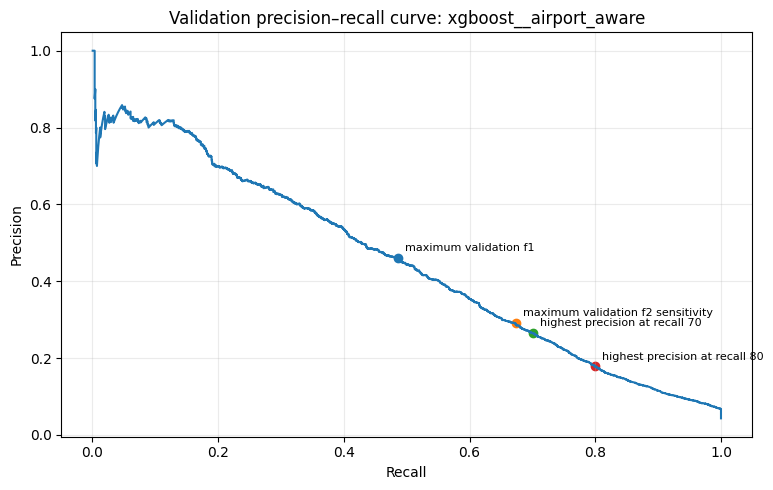

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve_table["recall"], curve_table["precision"])
for row in selected_thresholds.itertuples():
    ax.scatter(row.recall, row.precision)
    ax.annotate(
        row.rule.replace("_", " "),
        (row.recall, row.precision),
        xytext=(5, 5), textcoords="offset points", fontsize=8
    )
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Validation precision–recall curve: {SELECTED_KEY}")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 16. Confusion matrices at meaningful thresholds


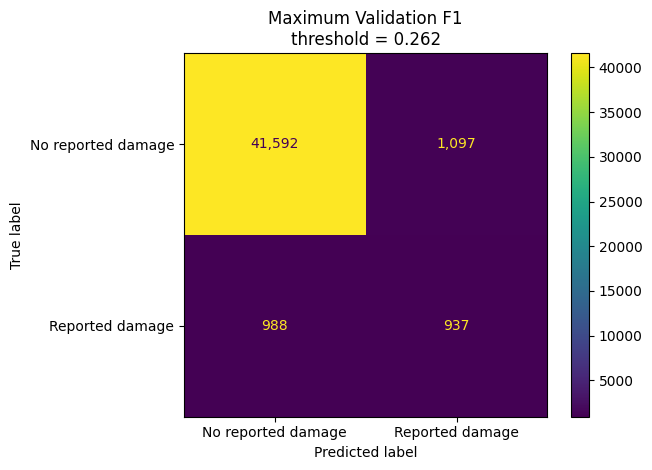

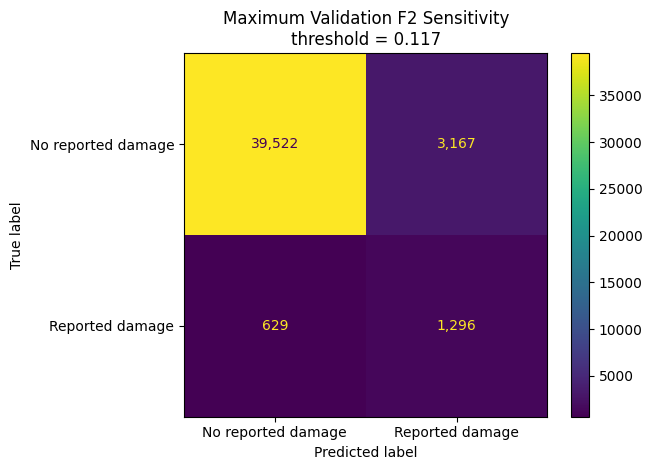

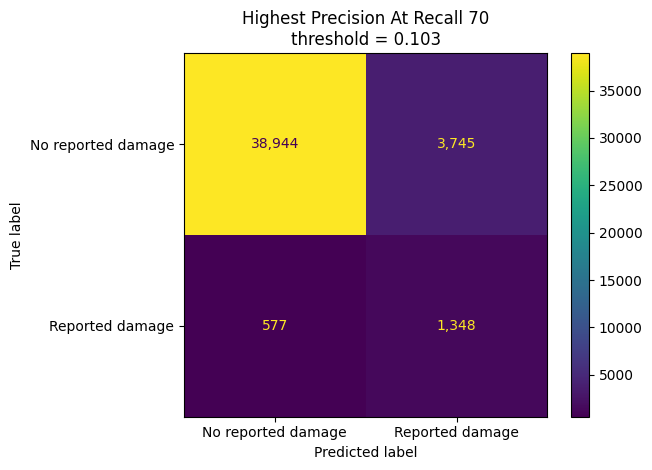

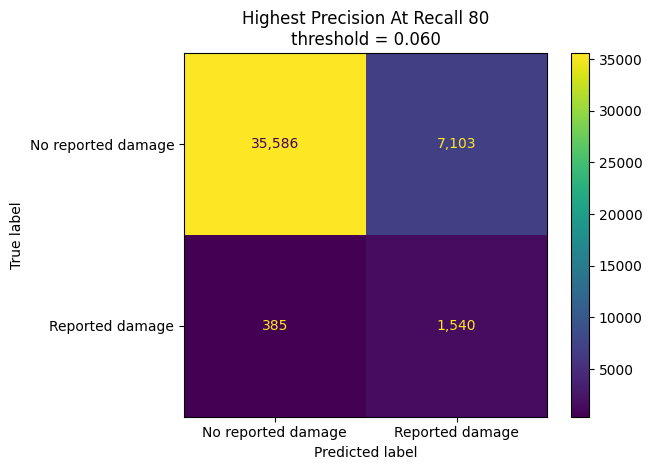

In [30]:
threshold_lookup = dict(zip(
    selected_thresholds["rule"], selected_thresholds["threshold"]
))
rules_to_plot = [
    "maximum_validation_f1",
    "maximum_validation_f2_sensitivity",
    "highest_precision_at_recall_70",
    "highest_precision_at_recall_80",
]

for rule in rules_to_plot:
    if rule not in threshold_lookup:
        continue
    threshold = threshold_lookup[rule]
    predictions = (selected_val_prob >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_validation, predictions,
        labels=[0, 1],
        display_labels=["No reported damage", "Reported damage"],
        values_format=","
    )
    plt.title(f"{rule.replace('_', ' ').title()}\nthreshold = {threshold:.3f}")
    plt.tight_layout()
    plt.show()

### Confusion-matrix observation

The confusion matrices make the threshold trade-off explicit. Lowering the
threshold increases true-positive detection but also increases false-positive
classification. The F1 threshold represents the most balanced operating point
under equal precision-recall weighting, whereas the F2 and 70%/80% recall
thresholds deliberately accept more false positives to reduce missed damage
cases.

No confusion matrix is treated as an operational recommendation at this stage;
the appropriate trade-off would depend on the eventual cost of a missed damage
event relative to a false alarm.

### Threshold decision

The maximum-F1 threshold is retained as the primary descriptive operating point
because the project does not currently define an operational cost ratio between
false negatives and false positives. It provides the strongest observed balance
between precision and recall on the validation period.

The F2, 70%-recall, and 80%-recall thresholds are retained as sensitivity
scenarios rather than competing model-selection rules. They demonstrate how
much additional false-positive burden would be accepted if detecting more
damaging strikes became the priority.

No threshold selected in this notebook is treated as a final operational policy.
Probability calibration and generalization must first be evaluated in
Notebook 06.

## 17. Save uncalibrated candidate pipelines for Notebook 06

The fitted candidate pipelines are saved in `models/candidates/`. These are
intermediate model artifacts rather than the final project model.

Each artifact contains both the fitted preprocessing pipeline and the fitted
classifier. Notebook 06 will load these candidates, compare calibration
methods, and perform chronological and airport-held-out validation before
saving one canonical calibrated pipeline in `models/final/`.


In [31]:
candidate_manifest = []

for candidate_key, pipeline in fitted_candidates.items():
    artifact_path = MODEL_DIR / f"{candidate_key}_uncalibrated.joblib"
    joblib.dump(pipeline, artifact_path)
    candidate_manifest.append({
        "candidate": candidate_key,
        "path": str(artifact_path),
        "selected_for_primary_calibration": candidate_key == SELECTED_KEY,
        "file_size_mb": artifact_path.stat().st_size / 1024**2,
    })

manifest_df = pd.DataFrame(candidate_manifest)
manifest_df.to_csv(
    OUTPUT_DIR / "uncalibrated_candidate_manifest.csv", index=False
)
display(manifest_df.round(2))

,candidate,path,selected_for_primary_calibration,file_size_mb
0,logistic__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.01
1,random_forest__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,498.61
2,xgboost__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,2.14
3,logistic__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.06
4,random_forest__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,426.90
5,xgboost__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,True,1.88


### Candidate-artifact observation

Model artifact size differs substantially across model families. The serialized
Random Forest candidates require approximately **427–499 MB**, whereas the
XGBoost candidates are approximately **2 MB** and the Logistic Regression
models are smaller still.

This does not affect statistical model selection, but it is relevant to later
deployment and reproducibility. The selected airport-aware XGBoost model is
therefore also comparatively compact, although its selection was based on
validation performance rather than file size.

## 18. Demonstration export: transformed model-input sample

This sample shows what the selected pipeline actually passes to its estimator after fitting preprocessing on the 1990–2018 training period.

The complete transformed matrix is not exported because sparse one-hot encoding—especially for airports—can create thousands of columns and a very large file. Instead, the notebook exports:

1. a reproducible sample of transformed training rows,
2. every transformed feature name,
3. dimensions and missing-value checks.

This is sufficient to demonstrate that the estimator receives a numerical matrix with no NaN values.


In [32]:
selected_feature_set = selected_row["feature_set"]
selected_features = FEATURE_SETS[selected_feature_set]

sample_source = df.loc[train_mask, selected_features].sample(
    n=min(1000, int(train_mask.sum())),
    random_state=SEED
)

fitted_preprocessor = selected_pipeline.named_steps["preprocess"]
transformed_sample = fitted_preprocessor.transform(sample_source)
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(transformed_sample, "toarray"):
    transformed_sample_array = transformed_sample.toarray()
else:
    transformed_sample_array = np.asarray(transformed_sample)

transformed_sample_df = pd.DataFrame(
    transformed_sample_array,
    columns=transformed_feature_names,
    index=sample_source.index
)
transformed_sample_df.insert(
    0, "INDEX_NR", df.loc[sample_source.index, "INDEX_NR"].to_numpy()
)

transformed_sample_path = (
    PROCESSED_DIR / "faa_strikes_training_matrix_sample.csv"
)
feature_manifest_path = (
    OUTPUT_DIR / "transformed_feature_manifest.csv"
)

transformed_sample_df.to_csv(transformed_sample_path, index=False)
pd.DataFrame({
    "feature_index": np.arange(len(transformed_feature_names)),
    "transformed_feature": transformed_feature_names
}).to_csv(feature_manifest_path, index=False)

transformed_info = pd.DataFrame([{
    "file": transformed_sample_path.name,
    "sample_rows": transformed_sample_df.shape[0],
    "columns_including_identifier": transformed_sample_df.shape[1],
    "transformed_model_features": len(transformed_feature_names),
    "file_size_mb": transformed_sample_path.stat().st_size / 1024**2,
    "nan_cells": int(transformed_sample_df.isna().sum().sum()),
    "purpose": "Demonstrate numerical input after training-fitted preprocessing"
}])
display(transformed_info.round(2))
display(transformed_sample_df.head())

assert transformed_sample_df.drop(columns="INDEX_NR").isna().sum().sum() == 0

,file,sample_rows,columns_including_identifier,transformed_model_features,file_size_mb,nan_cells,purpose
0,faa_strikes_training_matrix_sample.csv,1000,483,482,1.89,0,Demonstrate numerical input after training-fit...


,INDEX_NR,numeric__MONTH_SIN,numeric__MONTH_COS,numeric__NUM_ENGS,numeric__HEIGHT,numeric__SPEED,num_struck_ordinal__NUM_STRUCK,categorical__SEASON_Autumn,categorical__SEASON_Spring,categorical__SEASON_Summer,categorical__SEASON_Winter,categorical__WILDLIFE_TYPE_Bat,categorical__WILDLIFE_TYPE_Bird,categorical__WILDLIFE_TYPE_Other wildlife,categorical__WILDLIFE_TYPE_Reptile,categorical__WILDLIFE_TYPE_Terrestrial mammal,categorical__SIZE_Large,categorical__SIZE_Medium,categorical__SIZE_Not reported,categorical__SIZE_Small,categorical__AC_CLASS_A,categorical__AC_CLASS_B,categorical__AC_CLASS_Not reported,categorical__AC_CLASS_infrequent_sklearn,categorical__AC_MASS_GROUP_Heavy,categorical__AC_MASS_GROUP_Light,categorical__AC_MASS_GROUP_Medium,categorical__AC_MASS_GROUP_Unknown,categorical__TYPE_ENG_A,categorical__TYPE_ENG_B,categorical__TYPE_ENG_C,categorical__TYPE_ENG_D,categorical__TYPE_ENG_F,categorical__TYPE_ENG_Not reported,categorical__TYPE_ENG_infrequent_sklearn,categorical__WARNED_No,categorical__WARNED_Unknown,categorical__WARNED_Yes,categorical__PHASE_OF_FLIGHT_Approach,categorical__PHASE_OF_FLIGHT_Arrival,categorical__PHASE_OF_FLIGHT_Climb,categorical__PHASE_OF_FLIGHT_Departure,categorical__PHASE_OF_FLIGHT_Descent,categorical__PHASE_OF_FLIGHT_En Route,categorical__PHASE_OF_FLIGHT_Landing Roll,categorical__PHASE_OF_FLIGHT_Local,categorical__PHASE_OF_FLIGHT_Not reported,categorical__PHASE_OF_FLIGHT_Parked,categorical__PHASE_OF_FLIGHT_Take-off Run,categorical__PHASE_OF_FLIGHT_Taxi,categorical__TIME_OF_DAY_Dawn,categorical__TIME_OF_DAY_Day,categorical__TIME_OF_DAY_Dusk,categorical__TIME_OF_DAY_Night,categorical__TIME_OF_DAY_Not reported,categorical__SKY_No Cloud,categorical__SKY_Not reported,categorical__SKY_Overcast,categorical__SKY_Some Cloud,categorical__PRECIPITATION_Fog,"categorical__PRECIPITATION_Fog, Rain",categorical__PRECIPITATION_Not reported,categorical__PRECIPITATION_Rain,categorical__PRECIPITATION_Snow,categorical__PRECIPITATION_infrequent_sklearn,categorical__STATE_AK,categorical__STATE_AL,categorical__STATE_AR,categorical__STATE_AZ,categorical__STATE_BC,categorical__STATE_CA,categorical__STATE_CO,categorical__STATE_CT,categorical__STATE_DC,categorical__STATE_DE,...,categorical__AIRPORT_ID_KSFO,categorical__AIRPORT_ID_KSGF,categorical__AIRPORT_ID_KSGJ,categorical__AIRPORT_ID_KSHV,categorical__AIRPORT_ID_KSJC,categorical__AIRPORT_ID_KSLC,categorical__AIRPORT_ID_KSLE,categorical__AIRPORT_ID_KSMF,categorical__AIRPORT_ID_KSNA,categorical__AIRPORT_ID_KSPI,categorical__AIRPORT_ID_KSQL,categorical__AIRPORT_ID_KSRQ,categorical__AIRPORT_ID_KSTL,categorical__AIRPORT_ID_KSTP,categorical__AIRPORT_ID_KSTS,categorical__AIRPORT_ID_KSUS,categorical__AIRPORT_ID_KSUX,categorical__AIRPORT_ID_KSWF,categorical__AIRPORT_ID_KSYR,categorical__AIRPORT_ID_KTEB,categorical__AIRPORT_ID_KTKI,categorical__AIRPORT_ID_KTLH,categorical__AIRPORT_ID_KTMB,categorical__AIRPORT_ID_KTOL,categorical__AIRPORT_ID_KTPA,categorical__AIRPORT_ID_KTRI,categorical__AIRPORT_ID_KTTN,categorical__AIRPORT_ID_KTUL,categorical__AIRPORT_ID_KTUS,categorical__AIRPORT_ID_KTVC,categorical__AIRPORT_ID_KTWF,categorical__AIRPORT_ID_KTYR,categorical__AIRPORT_ID_KTYS,categorical__AIRPORT_ID_KUES,categorical__AIRPORT_ID_KUGN,categorical__AIRPORT_ID_KUNV,categorical__AIRPORT_ID_KVNY,categorical__AIRPORT_ID_KVQQ,categorical__AIRPORT_ID_KVRB,categorical__AIRPORT_ID_KXNA,categorical__AIRPORT_ID_KYIP,categorical__AIRPORT_ID_KYKM,categorical__AIRPORT_ID_LFPG,categorical__AIRPORT_ID_MMGL,categorical__AIRPORT_ID_MMMX,categorical__AIRPORT_ID_MMUN,categorical__AIRPORT_ID_MNMG,categorical__AIRPORT_ID_MPTO,categorical__AIRPORT_ID_MROC,categorical__AIRPORT_ID_MSLP,categorical__AIRPORT_ID_PAFA,categorical__AIRPORT_ID_PAJN,categorical__AIRPORT_ID_PANC,categorical__AIRPORT_ID_PASI,categorical__AIRPORT_ID_PGSN,categorical__AIRPORT_ID_PGUM,categorical__AIRPORT_ID_PHJH,categorical__AIRPORT_ID_PHJR,categorical__AIRPORT_ID_PHLI,categorical__AIRPORT_ID_PHMK,categorical__AIRPORT_ID_PHNL,categori

### Transformed-data observation

The selected airport-aware XGBoost pipeline transforms the original modelling
variables into **482 numerical model features** after training-fitted
preprocessing.

The demonstration export contains **1,000 observations** and **483 columns**
when the `INDEX_NR` identifier is included. No missing values remain in the
transformed sample.

The increase from the smaller set of original predictors to 482 model features
is mainly caused by one-hot encoding of categorical variables, particularly
high-cardinality fields such as airport identity.

This transformed CSV is included only to demonstrate the numerical
representation received by the estimator. It is not the authoritative
preprocessing object. The serialized pipeline retains the fitted imputers,
encoders, ordinal transformation, and model together and must therefore be used
for future prediction, calibration, and simulation.

## 19. Output inventory and dataset-size evidence


In [33]:
output_inventory = []

for path, purpose in [
    (premodel_path, "Readable cleaned pre-model dataset"),
    (transformed_sample_path, "No-NaN transformed training sample"),
    (feature_manifest_path, "Complete transformed feature names"),
    (OUTPUT_DIR / "logistic_chronological_cv_results.csv", "Logistic chronological-CV tuning evidence"),
    (OUTPUT_DIR / "random_forest_chronological_cv_results.csv", "Random Forest chronological-CV tuning evidence"),
    (OUTPUT_DIR / "xgboost_chronological_cv_results.csv", "XGBoost chronological-CV tuning evidence"),
    (OUTPUT_DIR / "internal_tuning_results.csv", "Combined chronological-CV tuning evidence"),
    (OUTPUT_DIR / "selected_hyperparameters_from_cv.csv", "CV-selected hyperparameter settings"),
    (OUTPUT_DIR / "cv_selected_settings_classification_report.csv", "Fixed-threshold classification-report summary"),
    (OUTPUT_DIR / "validation_model_comparison.csv", "Validation metrics"),
    (OUTPUT_DIR / "validation_probability_predictions.csv", "Probabilities for calibration"),
    (OUTPUT_DIR / "selected_model_thresholds.csv", "Threshold decision evidence"),
    (OUTPUT_DIR / "uncalibrated_candidate_manifest.csv", "Candidate model artifacts"),
]:
    if path.exists():
        output_inventory.append({
            "artifact": path.name,
            "rows": (
                sum(1 for _ in open(path, encoding="utf-8", errors="ignore")) - 1
                if path.suffix == ".csv" else np.nan
            ),
            "file_size_mb": path.stat().st_size / 1024**2,
            "purpose": purpose,
        })

output_inventory_df = pd.DataFrame(output_inventory)
output_inventory_df.to_csv(
    OUTPUT_DIR / "notebook05_output_inventory.csv", index=False
)
display(output_inventory_df.round(2))


,artifact,rows,file_size_mb,purpose
0,faa_strikes_binary_model_ready.csv,319107,55.39,Readable cleaned pre-model dataset
1,faa_strikes_training_matrix_sample.csv,1000,1.89,No-NaN transformed training sample
2,transformed_feature_manifest.csv,482,0.02,Complete transformed feature names
3,logistic_chronological_cv_results.csv,36,0.01,Logistic chronological-CV tuning evidence
4,random_forest_chronological_cv_results.csv,128,0.05,Random Forest chronological-CV tuning evidence
5,xgboost_chronological_cv_results.csv,512,0.24,XGBoost chronological-CV tuning evidence
6,internal_tuning_results.csv,676,0.31,Combined chronological-CV tuning evidence
7,selected_hyperparameters_from_cv.csv,6,0.00,CV-selected hyperparameter settings
8,cv_selected_settings_classification_report.csv,6,0.00,Fixed-threshold classification-report summary
9,validation_model_comparison.csv,7,0.00,Validation metrics


### Output and reproducibility summary

Notebook 05 produces the modelling evidence required for later validation and
calibration.

The readable pre-model dataset contains **319,107 rows** and is preserved as
the human-readable analytical input before learned preprocessing. A separate
1,000-row transformed sample and a 482-feature manifest demonstrate the
numerical representation used by the selected pipeline.

The chronological tuning searches produced:

- **36** Logistic Regression configurations,
- **128** Random Forest configurations,
- **512** XGBoost configurations,
- **676** configurations in the combined tuning evidence.

Six CV-selected model/feature-set combinations are retained for comparison.
Validation outputs contain probability predictions for all **44,614**
observations in the 2019–2021 period, together with the model-comparison table
and four selected threshold operating points.

All six fitted, uncalibrated candidate pipelines are saved under
`models/candidates/`. The airport-aware XGBoost candidate is marked as the
primary model for Notebook 06, but the alternative candidates remain available
for calibration and robustness comparisons.

These artifacts preserve the distinction between readable analytical data,
demonstration transformed data, tuning evidence, validation predictions, and
serialized predictive pipelines.

## 20. Interpretation and hand-off to Notebook 06

Expanding chronological cross-validation produced a consistent performance
ordering across model families. XGBoost achieved the strongest discrimination,
followed by Random Forest and Logistic Regression. The best CV result came from
the airport-aware XGBoost configuration with mean PR-AUC **0.4590**, compared
with **0.4442** for Random Forest and **0.4115** for Logistic Regression using
the same geographic representation.

The later 2019–2021 validation period preserved this ordering. Airport-aware
XGBoost achieved PR-AUC **0.4496**, ROC-AUC **0.9062**, Brier score **0.0305**,
and log loss **0.1152**. The majority-prior baseline achieved PR-AUC only
**0.0431**, demonstrating that the trained model provides substantial
discrimination beyond class prevalence.

Including exact airport identity produced only a modest incremental advantage.
Its validation PR-AUC gain was approximately **0.0061** for Logistic
Regression, effectively zero for Random Forest, and **0.0014** for XGBoost.
Airport identity should therefore be treated as potentially useful rather than
essential. Notebook 06 must specifically test whether this advantage survives
evaluation on airports not represented during fitting.

At the common 0.50 threshold, the selected XGBoost model had **62.5% precision**
but only **29.7% recall**, demonstrating why a fixed default threshold is not
appropriate for the imbalanced damage outcome. Validation threshold exploration
identified **0.2619** as the maximum-F1 operating point, providing **46.1%
precision**, **48.7% recall**, and F1 **0.4734**. More sensitivity-oriented
thresholds can increase recall to 70% or 80%, but with substantial reductions in
precision.

The airport-aware XGBoost pipeline is therefore carried forward as the primary
calibration candidate, while the extended-geographic XGBoost model remains an
important comparator. Notebook 06 will determine whether the predicted
probabilities are sufficiently calibrated and temporally/geographically robust
for downstream Monte Carlo simulation.

The **2022–2024 final-test period remained completely unused** during
hyperparameter tuning, validation model selection, and threshold selection.
It remains locked for the later generalization assessment.

## 21. Limitations

- The target represents **reported aircraft damage conditional on a reported wildlife strike**.
- The analysis is observational and supports prediction and association, not causal claims.
- Reporting practices and field completeness changed over time.
- Airport identity can improve fit by representing persistent local patterns, but it can also encourage memorization and poor behavior for unseen airports.
- `NUM_STRUCK` contains ordered ranges rather than exact counts.
- Class weighting changes model fitting and may affect raw calibration; this is one reason Notebook 06 is mandatory.
- Validation threshold choices do not create an operational policy. A real deployment would need explicit costs for missed damage and false alarms.
- The transformed CSV is a demonstration sample, not a replacement for the serialized preprocessing pipeline.


## References used for evaluation choices

- Davis, J., & Goadrich, M. (2006). *The Relationship Between Precision-Recall and ROC Curves*. ICML.
- Saito, T., & Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets*. PLOS ONE.
- Lipton, Z. C., Elkan, C., & Narayanaswamy, B. (2014). *Thresholding Classifiers to Maximize F1 Score*. arXiv:1402.1892 / ECML PKDD.
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting Good Probabilities with Supervised Learning*. ICML.
- scikit-learn documentation: precision-recall curves, average precision, probability calibration, and model evaluation.
- XGBoost documentation: scikit-learn estimator interface and imbalanced binary classification parameters.

